In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

### Functions needed in preprocessing

In [217]:
def calculating_iqr(data,column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    q2 = q3 - q1
    upper = q3 + (1.5 * q2)
    lower = q1 - (1.5 * q2)
    return lower,upper

In [218]:
handle_outliers = lambda x: lower if x < lower else(upper if x > upper else x)

In [219]:
def cal_col(data):
    num_col = data.select_dtypes(include=['float64','int64']).columns
    col = data.columns
    return col,num_col

In [220]:
def cal_corr(num_col,data,ann = True):
    corr = data[num_col].corr()
    sns.heatmap(data = corr, annot = ann)
    plt.show()

In [221]:
def dropping_col_based_on_nulls_precentage(data):
    threshold = data.shape[0] * 0.5
    col_to_drop = data.columns[data.isna().sum() >= threshold]
    data.drop(col_to_drop, inplace = True,axis = 1)
    return data

### reading files

In [222]:
country_wise_df = pd.read_csv('country_wise_latest.csv')

In [223]:
covid_19_clean_complete_df = pd.read_csv("covid_19_clean_complete.csv")

In [224]:
full_grouped_df = pd.read_csv('full_grouped.csv')

In [225]:
day_wise_df = pd.read_csv('day_wise.csv')

In [226]:
usa_county_wise_df = pd.read_csv('usa_county_wise.csv')

In [227]:
worldometer_data_df = pd.read_csv('worldometer_data.csv')

### Our target is to get confirmed cases over datasets

### Working with country_wise dataset

In [228]:
country_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [229]:
col,num_col = cal_col(country_wise_df)

In [230]:
country_wise_df.head(20)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe


In [231]:
country_wise_df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


from previous statistics measurements we will find out that there are outliers in most of these columns
let's start with ploting them
then calculating the IQR and apply Winsorizing

#### handling Outliers

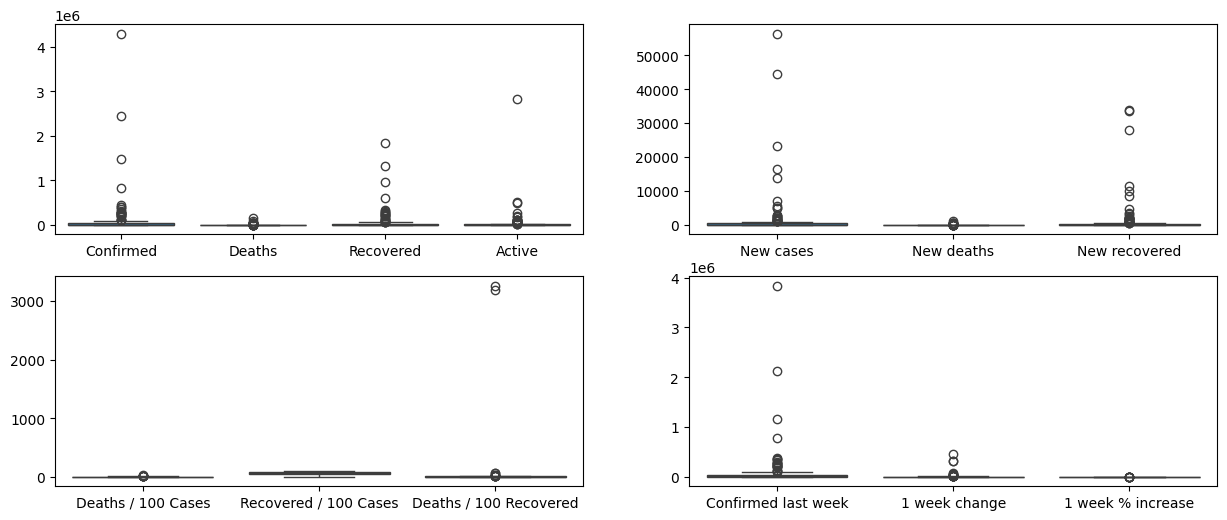

In [232]:
plt.figure(figsize=(15, 6))
plt.subplot(2,2,1)
sns.boxplot(data= country_wise_df[num_col[:4]])

plt.subplot(2,2,2)
sns.boxplot(data= country_wise_df[num_col[4:7]])

plt.subplot(2,2,3)
sns.boxplot(data= country_wise_df[num_col[7:10]])

plt.subplot(2,2,4)
sns.boxplot(data= country_wise_df[num_col[10:]])
plt.show()

In [233]:
for i in num_col:
    lower,upper = calculating_iqr(country_wise_df,i)
    country_wise_df[i] = country_wise_df[i].apply(handle_outliers)

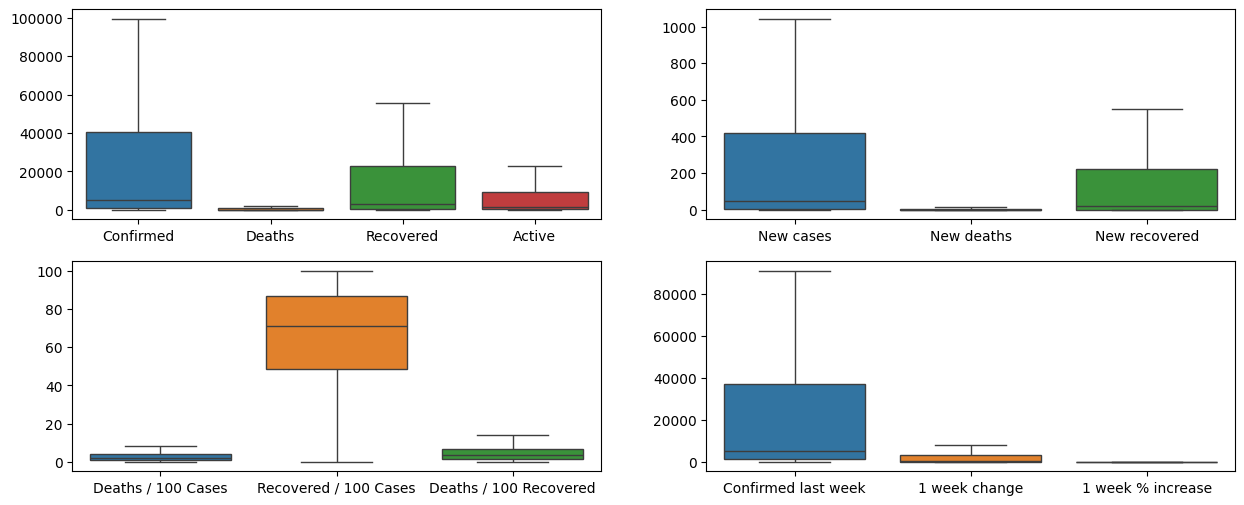

In [234]:
plt.figure(figsize=(15, 6))
plt.subplot(2,2,1)
sns.boxplot(data= country_wise_df[num_col[:4]])

plt.subplot(2,2,2)
sns.boxplot(data= country_wise_df[num_col[4:7]])

plt.subplot(2,2,3)
sns.boxplot(data= country_wise_df[num_col[7:10]])

plt.subplot(2,2,4)
sns.boxplot(data= country_wise_df[num_col[10:]])
plt.show()

In [235]:
country_wise_df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,25944.139037,510.172460,14132.883690,6266.176471,264.544118,3.802139,144.483957,2.697005,64.820535,4.768289,23604.331551,2022.684492,11.154225
std,35481.834416,700.605387,19846.563715,8514.912668,366.343842,5.496665,205.116423,2.255514,26.287694,4.249337,32536.210181,2773.982790,10.935053
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,-47.000000,-3.840000
25%,1114.000000,18.500000,626.500000,141.500000,4.000000,0.000000,0.000000,0.945000,48.770000,1.450000,1051.500000,49.000000,2.775000
50%,5059.000000,108.000000,2815.000000,1600.000000,49.000000,1.000000,22.000000,2.150000,71.320000,3.620000,5020.000000,432.000000,6.890000
75%,40460.500000,734.000000,22606.000000,9149.000000,419.500000,6.000000,221.000000,3.875000,86.885000,6.440000,37080.500000,3172.000000,16.855000
max,99480.250000,1807.250000,55575.250000,22660.250000,1042.750000,15.000000,552.500000,8.270000,100.000000,13.925000,91124.000000,7856.500000,37.975000


In [236]:
country_wise_df.drop_duplicates(keep = 'first',inplace = True)
country_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    float64
 2   Deaths                  187 non-null    float64
 3   Recovered               187 non-null    float64
 4   Active                  187 non-null    float64
 5   New cases               187 non-null    float64
 6   New deaths              187 non-null    float64
 7   New recovered           187 non-null    float64
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    float64
 12  1 week change           187 non-null    float64
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

#### Getting relations using correlation

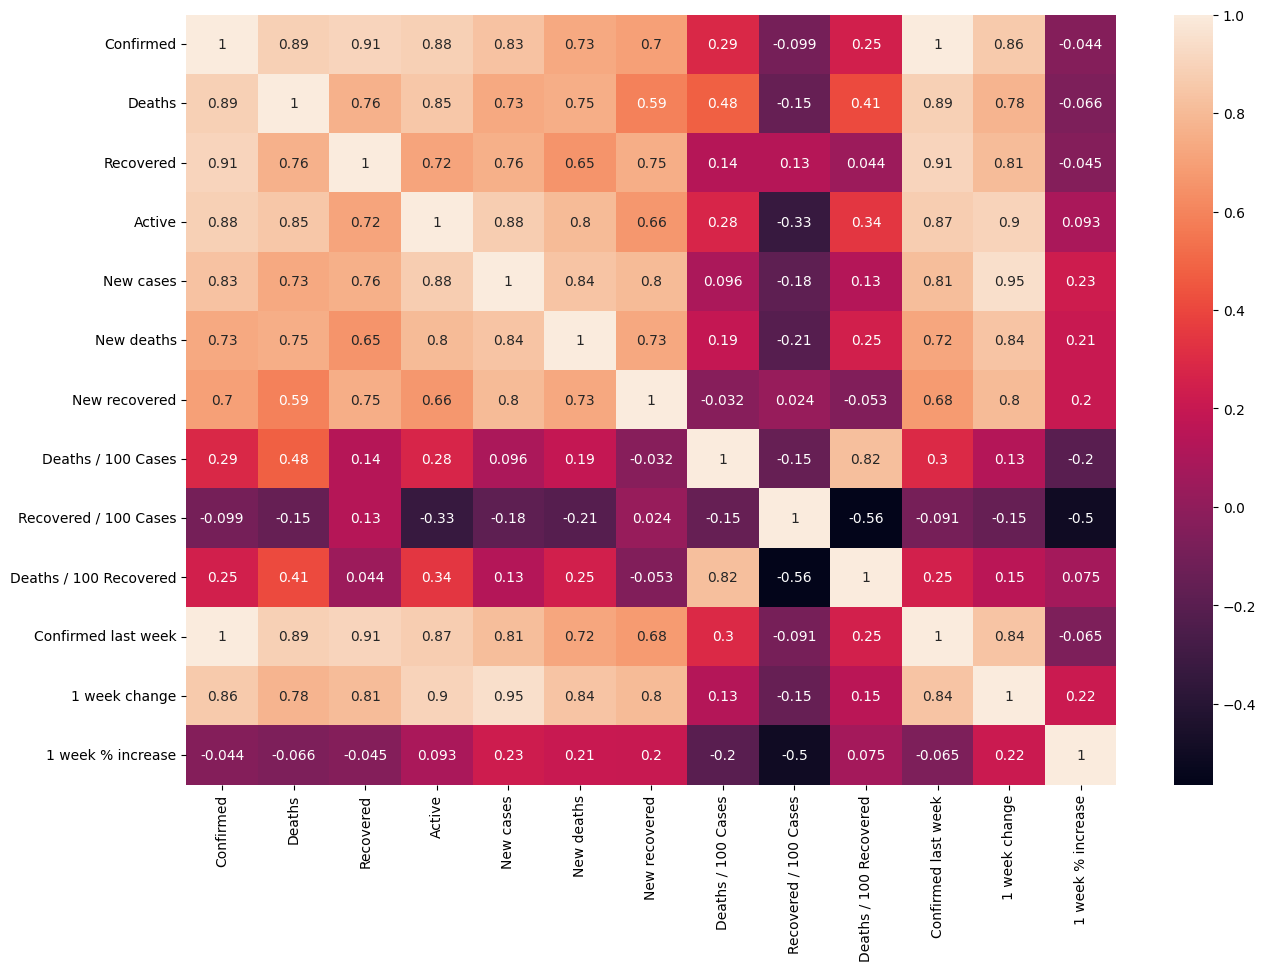

In [237]:
plt.figure(figsize=(15, 10))
cal_corr(num_col,country_wise_df)

In [238]:
col_to_remove_ind = [num_col[-1],num_col[-4],num_col[-5],num_col[-6]]
country_wise_df = country_wise_df.drop(col_to_remove_ind, axis=1)

In [239]:
max_countries_in_active_in_each_who_region = country_wise_df.groupby('WHO Region')['Country/Region'].agg({max_death := ('Deaths',"max"), max_confirmed := ('Confirmed','max'),max_recovered := ('Recovered','max')})
max_countries_in_active_in_each_who_region

,Confirmed,Recovered,Deaths
WHO Region,,,
Africa,Zimbabwe,Zimbabwe,Zimbabwe
Americas,Venezuela,Venezuela,Venezuela
Eastern Mediterranean,Yemen,Yemen,Yemen
Europe,Uzbekistan,Uzbekistan,Uzbekistan
South-East Asia,Timor-Leste,Timor-Leste,Timor-Leste
Western Pacific,Vietnam,Vietnam,Vietnam


In [240]:
max_countries_in_active_in_each_who_region_per = country_wise_df.groupby('WHO Region')['Country/Region'].agg({max_death_100_cases := ('Deaths / 100 Cases country',"max"), max_recover_100_cases := ('Recovered / 100 Cases country','max'),max_death_for_100_recover := ('Deaths / 100 Recovered country','max')})
max_countries_in_active_in_each_who_region_per

,Deaths / 100 Recovered country,Deaths / 100 Cases country,Recovered / 100 Cases country
WHO Region,,,
Africa,Zimbabwe,Zimbabwe,Zimbabwe
Americas,Venezuela,Venezuela,Venezuela
Eastern Mediterranean,Yemen,Yemen,Yemen
Europe,Uzbekistan,Uzbekistan,Uzbekistan
South-East Asia,Timor-Leste,Timor-Leste,Timor-Leste
Western Pacific,Vietnam,Vietnam,Vietnam


In [241]:
col,num_col = cal_col(country_wise_df)

In [242]:
country_wise_df[num_col].describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Confirmed last week,1 week change
count,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,25944.139037,510.172460,14132.883690,6266.176471,264.544118,3.802139,144.483957,23604.331551,2022.684492
std,35481.834416,700.605387,19846.563715,8514.912668,366.343842,5.496665,205.116423,32536.210181,2773.982790
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,-47.000000
25%,1114.000000,18.500000,626.500000,141.500000,4.000000,0.000000,0.000000,1051.500000,49.000000
50%,5059.000000,108.000000,2815.000000,1600.000000,49.000000,1.000000,22.000000,5020.000000,432.000000
75%,40460.500000,734.000000,22606.000000,9149.000000,419.500000,6.000000,221.000000,37080.500000,3172.000000
max,99480.250000,1807.250000,55575.250000,22660.250000,1042.750000,15.000000,552.500000,91124.000000,7856.500000


In [243]:
who_reg_val = country_wise_df['WHO Region'].unique()
who_reg_val

array(['Eastern Mediterranean', 'Europe', 'Africa', 'Americas',
       'Western Pacific', 'South-East Asia'], dtype=object)

#### Plotting

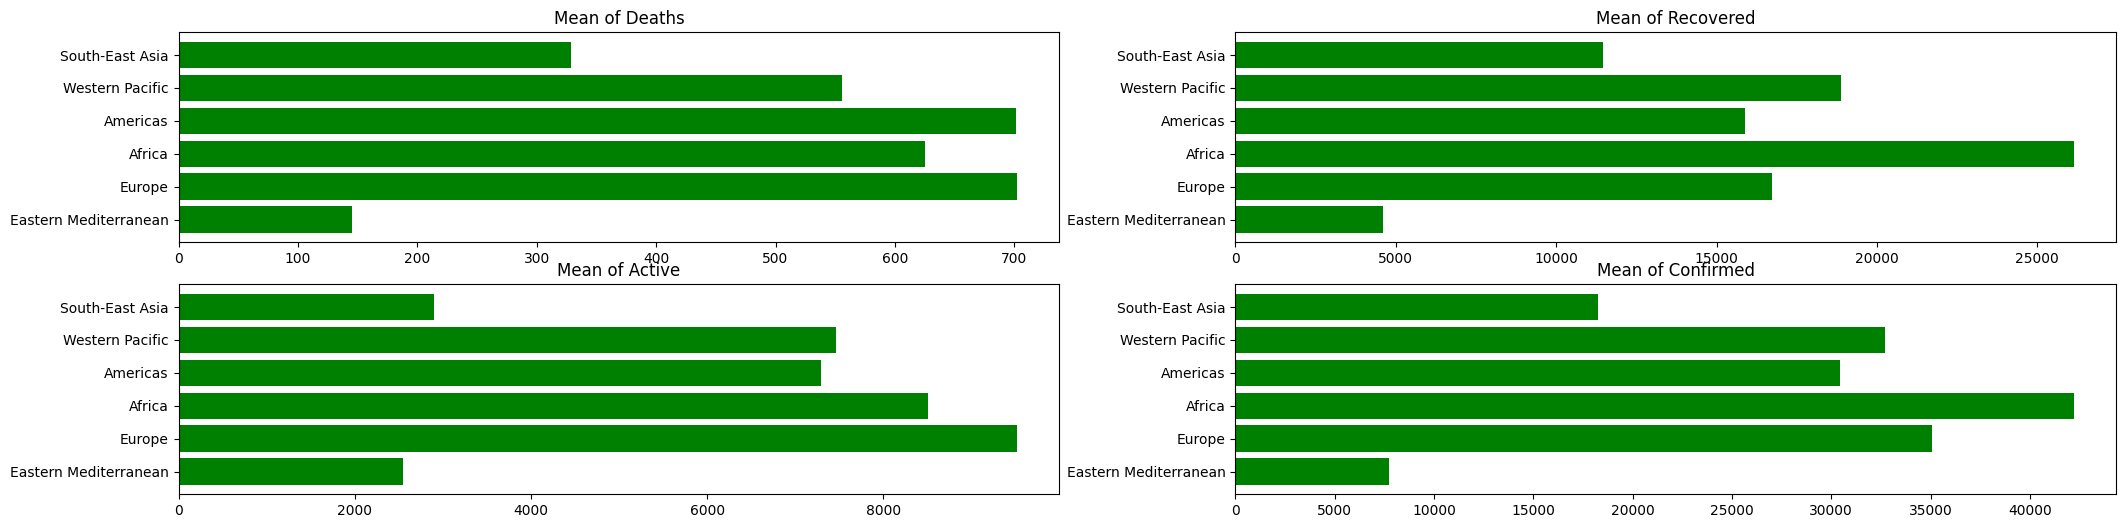

In [244]:
plt.figure(figsize=(25, 6))
plt.subplot(2,2,1)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Deaths'].mean(),color = 'green')
plt.title('Mean of Deaths')

plt.subplot(2,2,2)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Recovered'].mean(),color = 'green')
plt.title('Mean of Recovered')

plt.subplot(2,2,3)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Active'].mean(),color = 'green')
plt.title('Mean of Active')

plt.subplot(2,2,4)
plt.barh(who_reg_val,country_wise_df.groupby('WHO Region')['Confirmed'].mean(),color = 'green')
plt.title('Mean of Confirmed')

plt.show()

In [245]:
countries = list(x for x in max_countries_in_active_in_each_who_region["Recovered"])
countries

['Zimbabwe', 'Venezuela', 'Yemen', 'Uzbekistan', 'Timor-Leste', 'Vietnam']

In [246]:
y = country_wise_df[ country_wise_df['Country/Region'].isin(countries)]

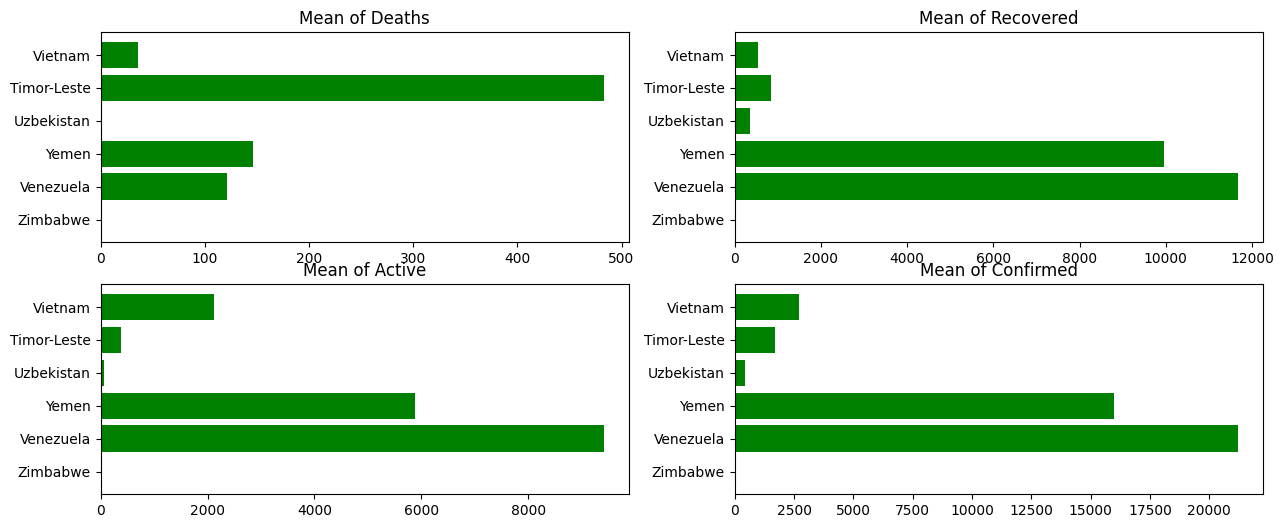

In [247]:
plt.figure(figsize=(15, 6))

plt.subplot(2,2,1)
plt.barh(countries, y['Deaths'],color = 'green')
plt.title('Mean of Deaths')

plt.subplot(2,2,2)
plt.barh(countries, y['Recovered'],color = 'green')
plt.title('Mean of Recovered')

plt.subplot(2,2,3)
plt.barh(countries, y['Active'],color = 'green')
plt.title('Mean of Active')

plt.subplot(2,2,4)
plt.barh(countries, y['Confirmed'],color = 'green')
plt.title('Mean of Confirmed')

plt.show()

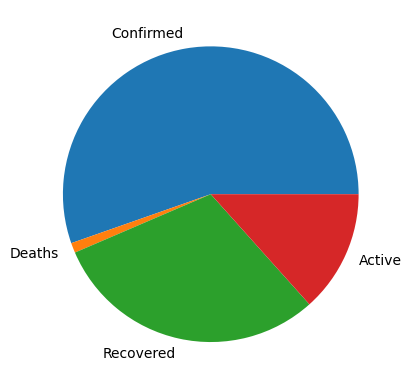

In [248]:
plt.pie(country_wise_df[num_col[:4]].sum(),labels = num_col[:4])
plt.show()

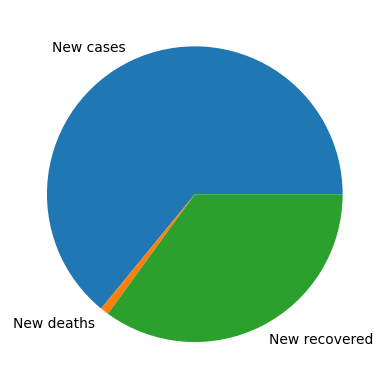

In [249]:
plt.pie(country_wise_df[num_col[4:7]].sum(),labels = num_col[4:7])
plt.show()

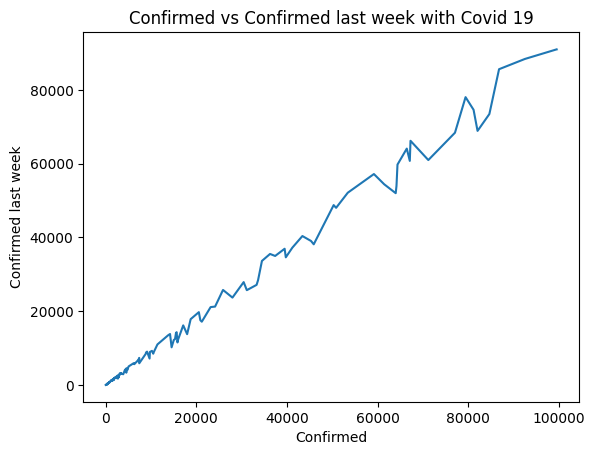

In [250]:
sns.lineplot(x='Confirmed', y='Confirmed last week', data=country_wise_df)
plt.title("Confirmed vs Confirmed last week with Covid 19")
plt.show()

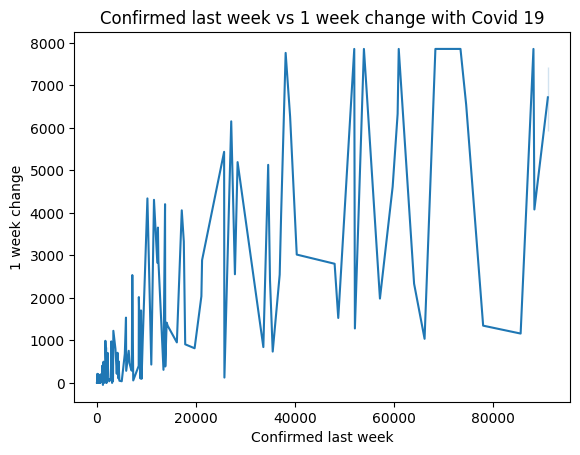

In [251]:
sns.lineplot(x='Confirmed last week', y='1 week change', data=country_wise_df)
plt.title("Confirmed last week vs 1 week change with Covid 19")
plt.show()

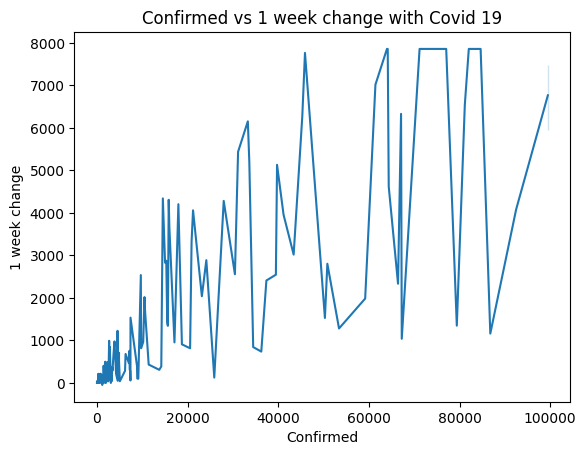

In [252]:
sns.lineplot(x='Confirmed', y='1 week change', data=country_wise_df)
plt.title("Confirmed vs 1 week change with Covid 19")
plt.show()

In [253]:
d1 = country_wise_df
d1.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Confirmed last week',
       '1 week change', 'WHO Region'],
      dtype='object')

#### Analysis Results:
* The highest WHO Region in
    * 'Total cases' of Covid 19
        1. Africa
        2. Europe
    * 'Total active'
        1. Europe
        2. Africa
    * 'Total recovered'
        1. Europe
        2. Western Pacific
    * 'Total deaths'
        1. Europe
        2. Americans
*  For each WHO region has x countries and for the maximum value in each one:
    * for total recovered column
        1. Venezuela
        2. Yemen
    * for total cases column
        1. Venezuela
        2. Yemen
    * for Total deaths column
        1. Timor-Leste
        2. Yemen
    * for active column
        1. Venezuela
        2. Yemen
* Over weeks the number of confirmed cases are increasing
* Deaths has the lowest precentage over the different cases
* Recovered cases have the second highest percentage over time
* Columns that high correlated with Confirmed column are (Country/Region, Confirmed, Deaths, Recovered, Active, New cases, New deaths, New recovered, Confirmed last week, 1 week change, WHO Region, Total cases, Total deaths, Total recovered, Total active)

### Working with covid_19_clean_complete dataset

In [254]:
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [255]:
row = covid_19_clean_complete_df.shape[0]
nu = covid_19_clean_complete_df['Province/State'].isnull().sum()
non_null = row - nu
percent_state = (non_null / row) * 100
percent_state

np.float64(29.88505747126437)

As the percentage of column Province/State is 29% then it is best to drop the column

In [256]:
covid_19_clean_complete_df = covid_19_clean_complete_df.drop(columns = ['Province/State'])

In [257]:
col,num_col = cal_col(covid_19_clean_complete_df)

In [258]:
covid_19_clean_complete_df.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [259]:
covid_19_clean_complete_df.tail()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


In [260]:
covid_19_clean_complete_df['Date'] = pd.to_datetime(covid_19_clean_complete_df['Date'])

In [261]:
country = covid_19_clean_complete_df['Country/Region'].unique()
country

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Brazil', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Greenland', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala',
       'Guinea', 'Guyana', 'Haiti', 'Holy See', 'Honduras', 'Hungary',
       'Iceland', 'India', 'Ind

In [262]:
covid_19_clean_complete_df.loc[covid_19_clean_complete_df['Country/Region'].isin(['Congo (Brazzaville)','Congo (Kinshasa)']),'Country/Region'] = 'Congo'
covid_19_clean_complete_df.loc[covid_19_clean_complete_df['Country/Region'].isin(['Holy See']),'Country/Region'] = 'Côte d\'Ivoire'
covid_19_clean_complete_df.loc[covid_19_clean_complete_df['Country/Region'].isin(['Burma']),'Country/Region'] = 'Myanmar'
covid_19_clean_complete_df.loc[covid_19_clean_complete_df['Country/Region'].isin(['Swaziland']),'Country/Region'] = 'Eswatini'
covid_19_clean_complete_df.loc[covid_19_clean_complete_df['Country/Region'].isin(['US']),'Country/Region'] = 'USA'

In [263]:
covid_19_clean_complete_df.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


In [264]:
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


In [265]:
num_col

Index(['Lat', 'Long', 'Confirmed', 'Deaths', 'Recovered', 'Active'], dtype='object')

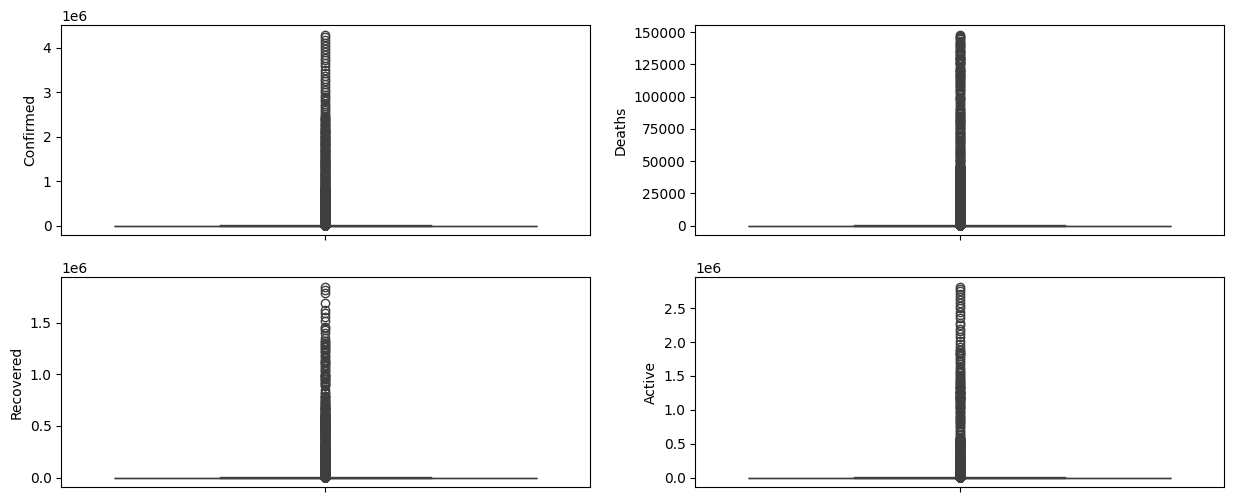

In [266]:
# Ploting before handling outliers
plt.figure(figsize=(15, 6))
plt.subplot(2,2,1)
sns.boxplot(data= covid_19_clean_complete_df[num_col[2]])

plt.subplot(2,2,2)
sns.boxplot(data= covid_19_clean_complete_df[num_col[3]])

plt.subplot(2,2,3)
sns.boxplot(data= covid_19_clean_complete_df[num_col[4]])

plt.subplot(2,2,4)
sns.boxplot(data= covid_19_clean_complete_df[num_col[5]])
plt.show()

In [267]:
lower,upper = calculating_iqr(covid_19_clean_complete_df,num_col[2])
covid_19_clean_complete_df[num_col[2]] = covid_19_clean_complete_df[num_col[2]].apply(handle_outliers)

lower,upper = calculating_iqr(covid_19_clean_complete_df,num_col[3])
covid_19_clean_complete_df[num_col[3]] = covid_19_clean_complete_df[num_col[3]].apply(handle_outliers)

lower,upper = calculating_iqr(covid_19_clean_complete_df,num_col[4])
covid_19_clean_complete_df[num_col[4]] = covid_19_clean_complete_df[num_col[4]].apply(handle_outliers)

lower,upper = calculating_iqr(covid_19_clean_complete_df,num_col[5])
covid_19_clean_complete_df[num_col[5]] = covid_19_clean_complete_df[num_col[5]].apply(handle_outliers)

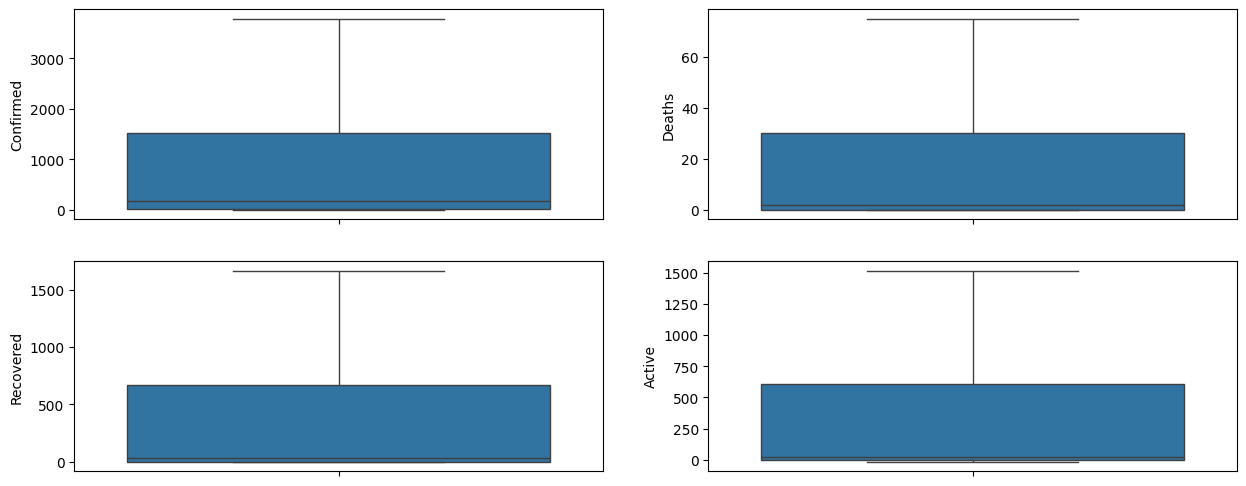

In [268]:
# Ploting after handling outliers
plt.figure(figsize=(15, 6))
plt.subplot(2,2,1)
sns.boxplot(data= covid_19_clean_complete_df[num_col[2]])

plt.subplot(2,2,2)
sns.boxplot(data= covid_19_clean_complete_df[num_col[3]])

plt.subplot(2,2,3)
sns.boxplot(data= covid_19_clean_complete_df[num_col[4]])

plt.subplot(2,2,4)
sns.boxplot(data= covid_19_clean_complete_df[num_col[5]])
plt.show()

In [269]:
covid_19_clean_complete_df.drop_duplicates(keep = 'first',inplace = True)
covid_19_clean_complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  float64       
 5   Deaths          49068 non-null  float64       
 6   Recovered       49068 non-null  float64       
 7   Active          49068 non-null  float64       
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 3.4+ MB


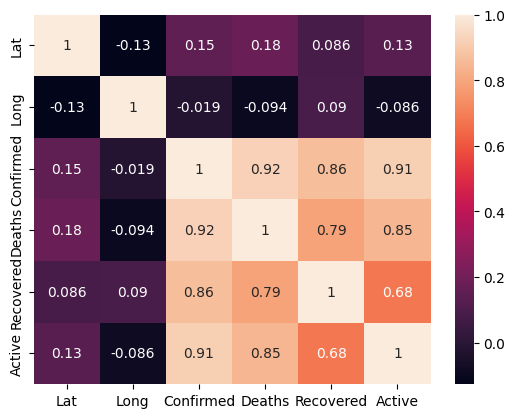

In [270]:
cal_corr(num_col,covid_19_clean_complete_df)

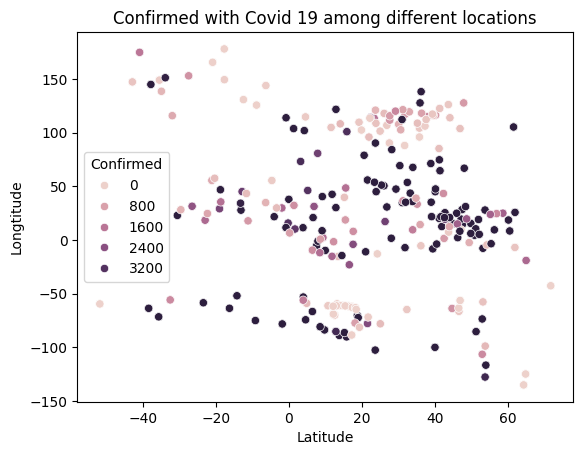

In [271]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Confirmed', data=covid_19_clean_complete_df)
plt.title("Confirmed with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

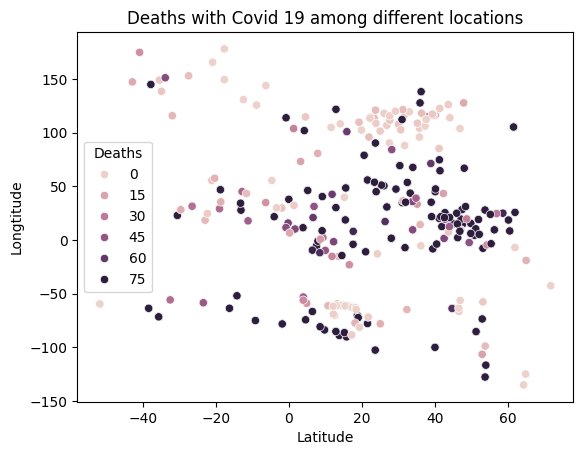

In [272]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Deaths', data=covid_19_clean_complete_df)
plt.title("Deaths with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

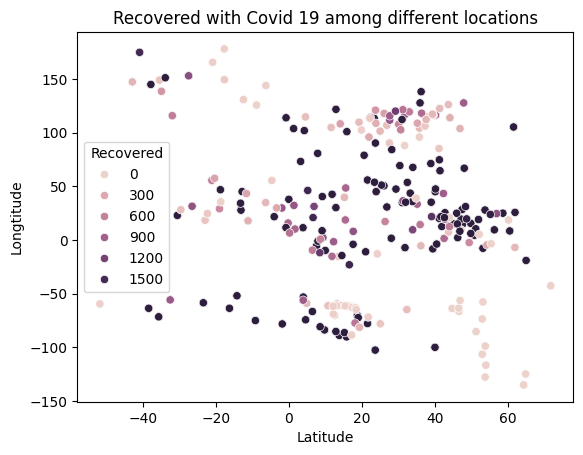

In [273]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Recovered', data=covid_19_clean_complete_df)
plt.title("Recovered with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

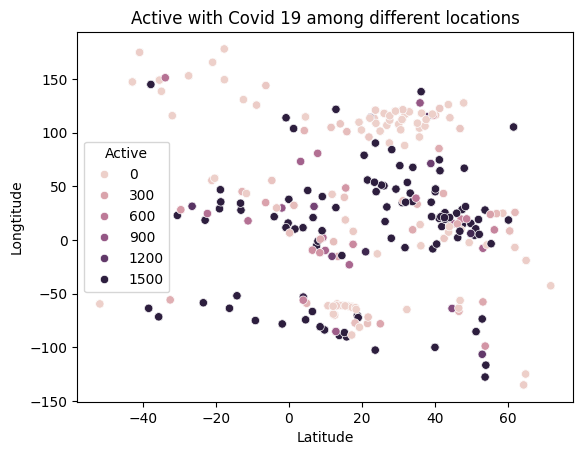

In [274]:
sns.scatterplot(x= 'Lat', y='Long',hue = 'Active', data=covid_19_clean_complete_df)
plt.title("Active with Covid 19 among different locations")
plt.xlabel('Latitude')
plt.ylabel('Longtitude')
plt.show()

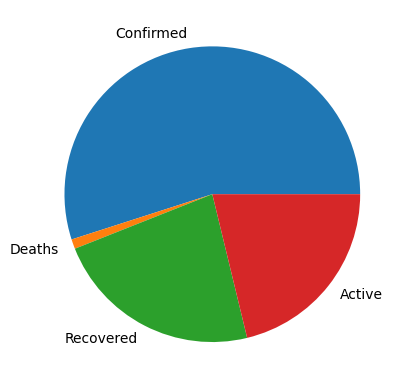

In [275]:
plt.pie(covid_19_clean_complete_df[num_col[2:]].sum(),labels = num_col[2:])
plt.show()

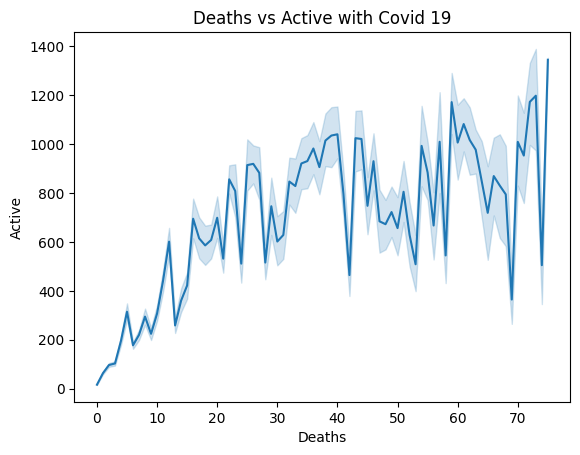

In [276]:
sns.lineplot(x='Deaths', y='Active', data=covid_19_clean_complete_df)
plt.title("Deaths vs Active with Covid 19")
plt.show()

In [277]:
col_to_remove_ind = [num_col[0],num_col[1]]
d2 = covid_19_clean_complete_df.drop(col_to_remove_ind, axis=1)

In [278]:
d2.columns

Index(['Country/Region', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'WHO Region'],
      dtype='object')

##### From previous analysis we found that
* high relationship between different cases for people with covid 19
* the location doesn't make an enough reason for having Covid 19
* Deaths for having Covid 19 take the least percentage
* There isn't high correlation between target and columns: lat,long so they will be removed

### Working with day_wise dataset

In [279]:
col,num_col = cal_col(day_wise_df)

In [280]:
day_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    188 non-null    object 
 1   Confirmed               188 non-null    int64  
 2   Deaths                  188 non-null    int64  
 3   Recovered               188 non-null    int64  
 4   Active                  188 non-null    int64  
 5   New cases               188 non-null    int64  
 6   New deaths              188 non-null    int64  
 7   New recovered           188 non-null    int64  
 8   Deaths / 100 Cases      188 non-null    float64
 9   Recovered / 100 Cases   188 non-null    float64
 10  Deaths / 100 Recovered  188 non-null    float64
 11  No. of countries        188 non-null    int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 17.8+ KB


In [281]:
day_wise_df['Date'] = pd.to_datetime(day_wise_df['Date'])

In [282]:
day_wise_df.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


In [283]:
day_wise_df['Date'].min()

Timestamp('2020-01-22 00:00:00')

In [284]:
day_wise_df['Date'].max()

Timestamp('2020-07-27 00:00:00')

In [285]:
day_wise_df[num_col].describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
count,1.880000e+02,188.000000,1.880000e+02,1.880000e+02,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,4.406960e+06,230770.760638,2.066001e+06,2.110188e+06,87771.021277,3478.824468,50362.015957,4.860638,34.343936,22.104521,144.351064
std,4.757988e+06,217929.094183,2.627976e+06,1.969670e+06,75295.293255,2537.735652,56090.892479,1.579541,16.206159,22.568307,65.175979
min,5.550000e+02,17.000000,2.800000e+01,5.100000e+02,0.000000,0.000000,0.000000,2.040000,1.710000,6.260000,6.000000
25%,1.121910e+05,3935.000000,6.044125e+04,5.864175e+04,5568.500000,250.750000,2488.250000,3.510000,22.785000,9.650000,101.250000
50%,2.848733e+06,204190.000000,7.847840e+05,1.859759e+06,81114.000000,4116.000000,30991.500000,4.850000,35.680000,15.380000,184.000000
75%,7.422046e+06,418634.500000,3.416396e+06,3.587015e+06,131502.500000,5346.000000,79706.250000,6.297500,48.945000,25.342500,187.000000
max,1.648048e+07,654036.000000,9.468087e+06,6.358362e+06,282756.000000,9966.000000,284394.000000,7.180000,57.450000,134.430000,187.000000


#### Handling Outliers

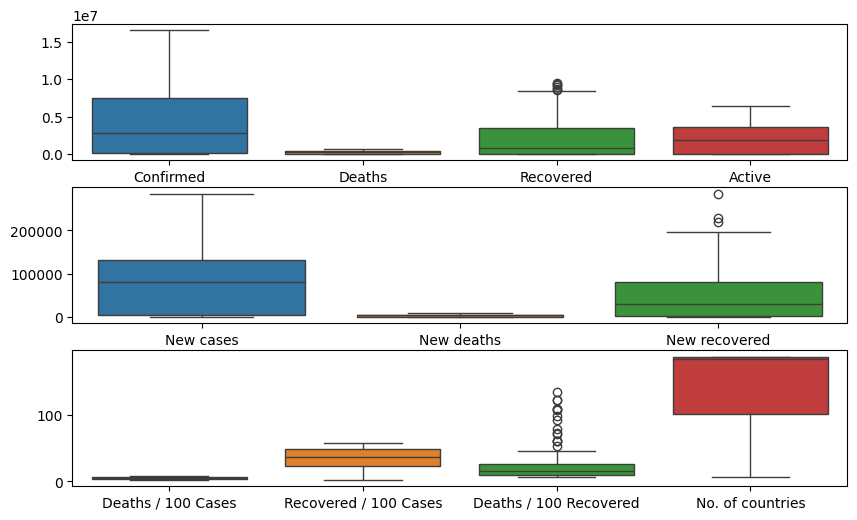

In [286]:
plt.figure(figsize=(10, 6))
plt.subplot(3,1,1)
sns.boxplot(data= day_wise_df[num_col[:4]])

plt.subplot(3,1,2)
sns.boxplot(data= day_wise_df[num_col[4:7]])

plt.subplot(3,1,3)
sns.boxplot(data= day_wise_df[num_col[7:]])

plt.show()

In [287]:
lower,upper = calculating_iqr(day_wise_df,num_col[0])
day_wise_df[num_col[0]] = day_wise_df[num_col[0]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[1])
day_wise_df[num_col[1]] = day_wise_df[num_col[1]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[2])
day_wise_df[num_col[2]] = day_wise_df[num_col[2]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[3])
day_wise_df[num_col[3]] = day_wise_df[num_col[3]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[4])
day_wise_df[num_col[4]] = day_wise_df[num_col[4]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[5])
day_wise_df[num_col[5]] = day_wise_df[num_col[5]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[6])
day_wise_df[num_col[6]] = day_wise_df[num_col[6]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[7])
day_wise_df[num_col[7]] = day_wise_df[num_col[7]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[8])
day_wise_df[num_col[8]] = day_wise_df[num_col[8]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[9])
day_wise_df[num_col[9]] = day_wise_df[num_col[9]].apply(handle_outliers)

lower,upper = calculating_iqr(day_wise_df,num_col[10])
day_wise_df[num_col[10]] = day_wise_df[num_col[10]].apply(handle_outliers)

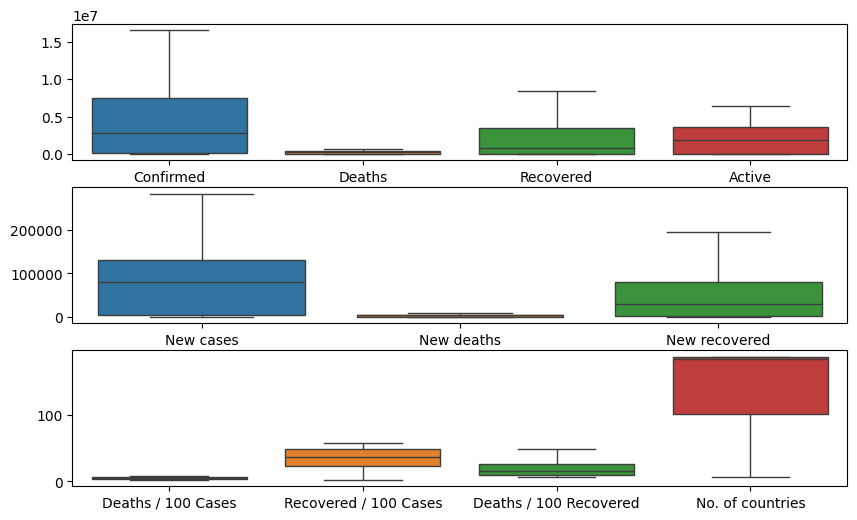

In [288]:
plt.figure(figsize=(10, 6))
plt.subplot(3,1,1)
sns.boxplot(data= day_wise_df[num_col[:4]])

plt.subplot(3,1,2)
sns.boxplot(data= day_wise_df[num_col[4:7]])

plt.subplot(3,1,3)
sns.boxplot(data= day_wise_df[num_col[7:]])

plt.show()

In [289]:
day_wise_df.drop_duplicates(keep = 'first',inplace = True)
day_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    188 non-null    datetime64[ns]
 1   Confirmed               188 non-null    int64         
 2   Deaths                  188 non-null    int64         
 3   Recovered               188 non-null    float64       
 4   Active                  188 non-null    int64         
 5   New cases               188 non-null    int64         
 6   New deaths              188 non-null    int64         
 7   New recovered           188 non-null    float64       
 8   Deaths / 100 Cases      188 non-null    float64       
 9   Recovered / 100 Cases   188 non-null    float64       
 10  Deaths / 100 Recovered  188 non-null    float64       
 11  No. of countries        188 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(6)
memory 

#### PLotting

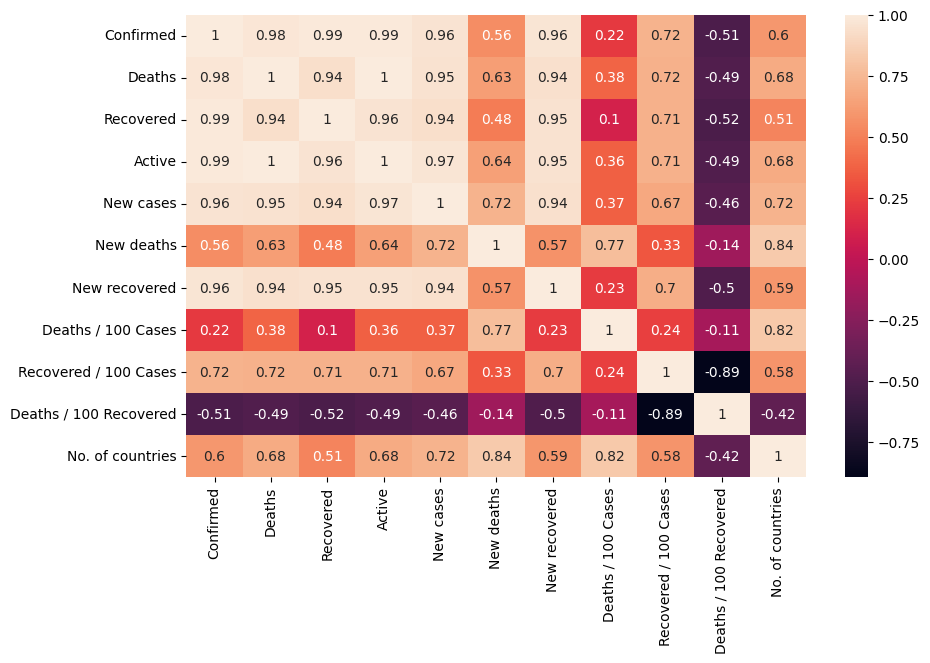

In [290]:
plt.figure(figsize=(10, 6))
cal_corr(num_col,day_wise_df)

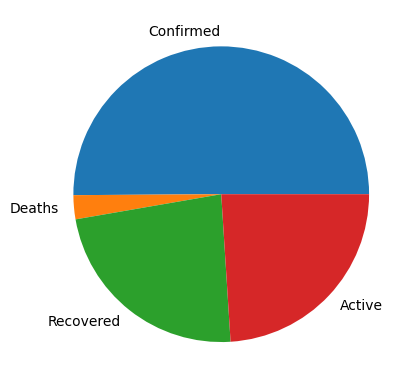

In [291]:
plt.pie(day_wise_df[num_col[:4]].sum(),labels = num_col[:4])
plt.show()

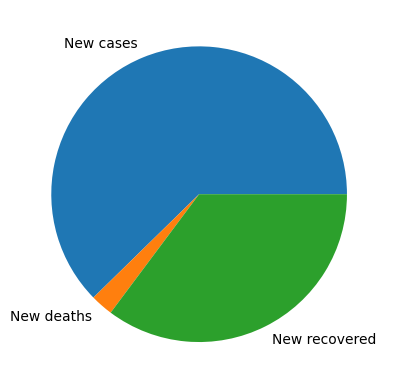

In [292]:
plt.pie(day_wise_df[num_col[4:7]].sum(),labels = num_col[4:7])
plt.show()

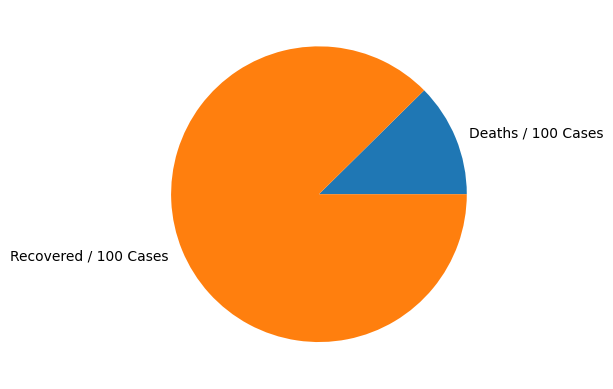

In [293]:
plt.pie(day_wise_df[num_col[7:9]].sum(),labels = num_col[7:9])
plt.show()

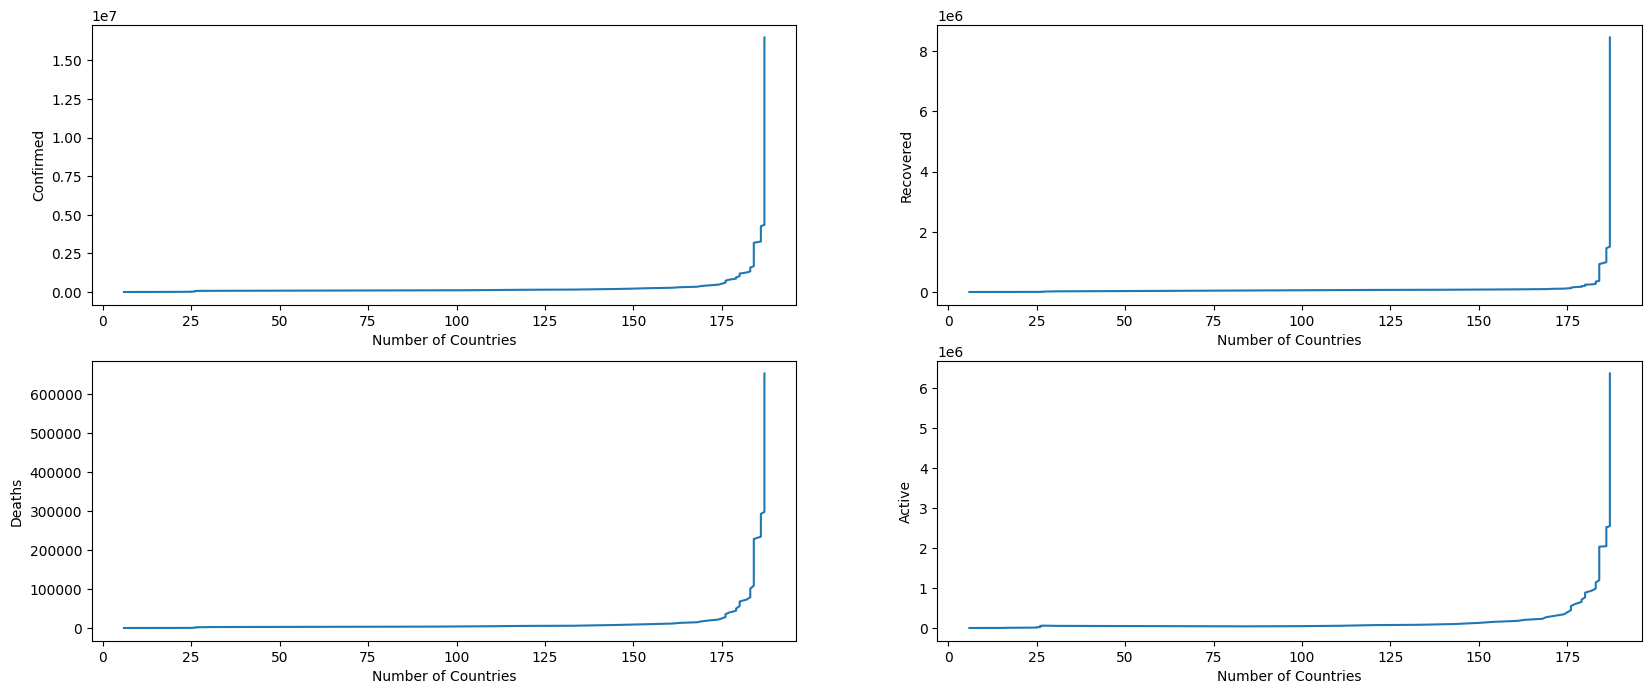

In [294]:
plt.figure(figsize=(20, 8))

plt.subplot(2, 2, 1)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[0]])
plt.xlabel("Number of Countries")
plt.ylabel("Confirmed")

plt.subplot(2, 2, 2)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[2]])
plt.xlabel("Number of Countries")
plt.ylabel("Recovered")

plt.subplot(2, 2, 3)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[1]])
plt.xlabel("Number of Countries")
plt.ylabel("Deaths")

plt.subplot(2, 2, 4)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[3]])
plt.xlabel("Number of Countries")
plt.ylabel("Active")
plt.show()

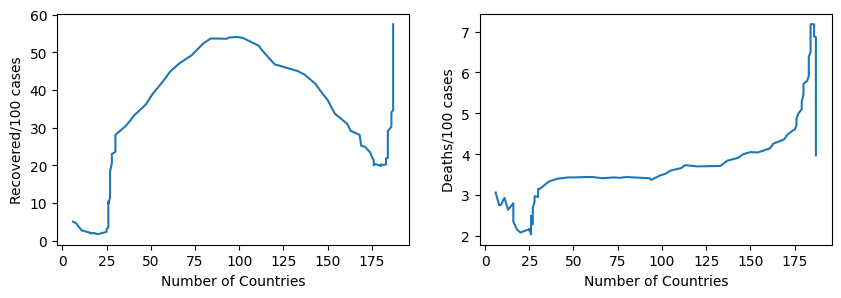

In [295]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[-3]])
plt.xlabel("Number of Countries")
plt.ylabel("Recovered/100 cases")

plt.subplot(1, 2, 2)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[-4]])
plt.xlabel("Number of Countries")
plt.ylabel("Deaths/100 cases")

plt.show()

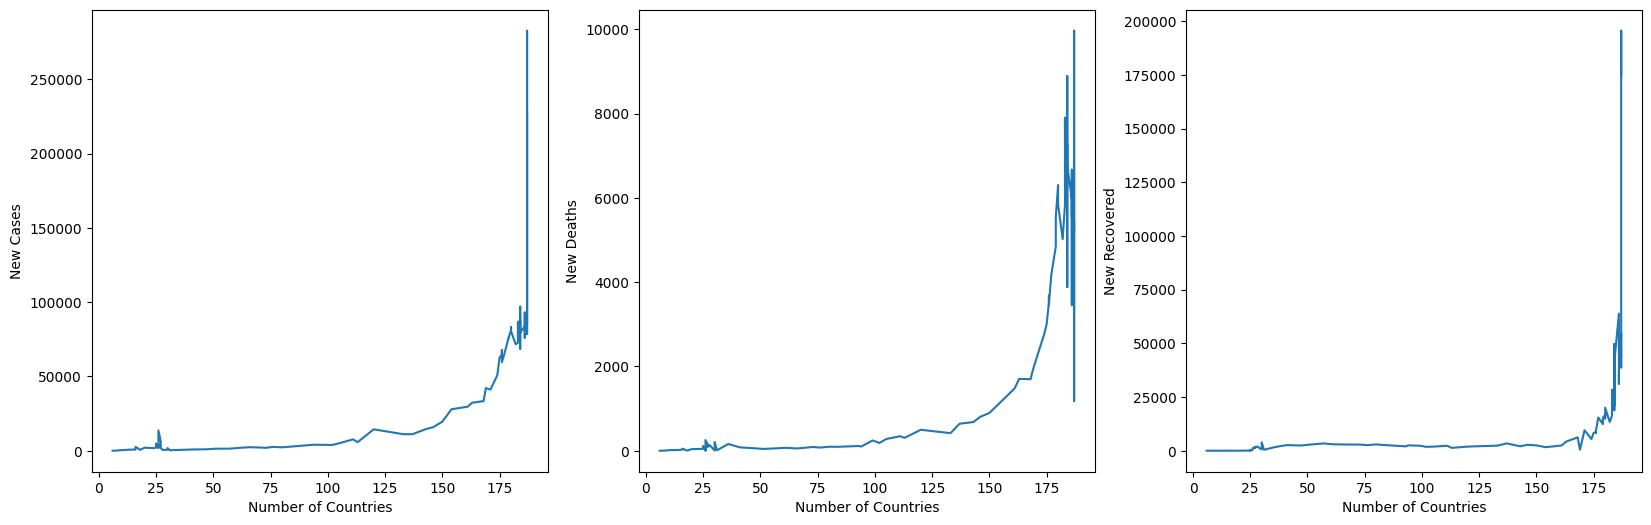

In [296]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[4]])
plt.xlabel("Number of Countries")
plt.ylabel("New Cases")

plt.subplot(1, 3, 2)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[5]])
plt.xlabel("Number of Countries")
plt.ylabel("New Deaths")

plt.subplot(1, 3, 3)
plt.plot(day_wise_df[num_col[-1]], day_wise_df[num_col[6]])
plt.xlabel("Number of Countries")
plt.ylabel("New Recovered")

plt.show()

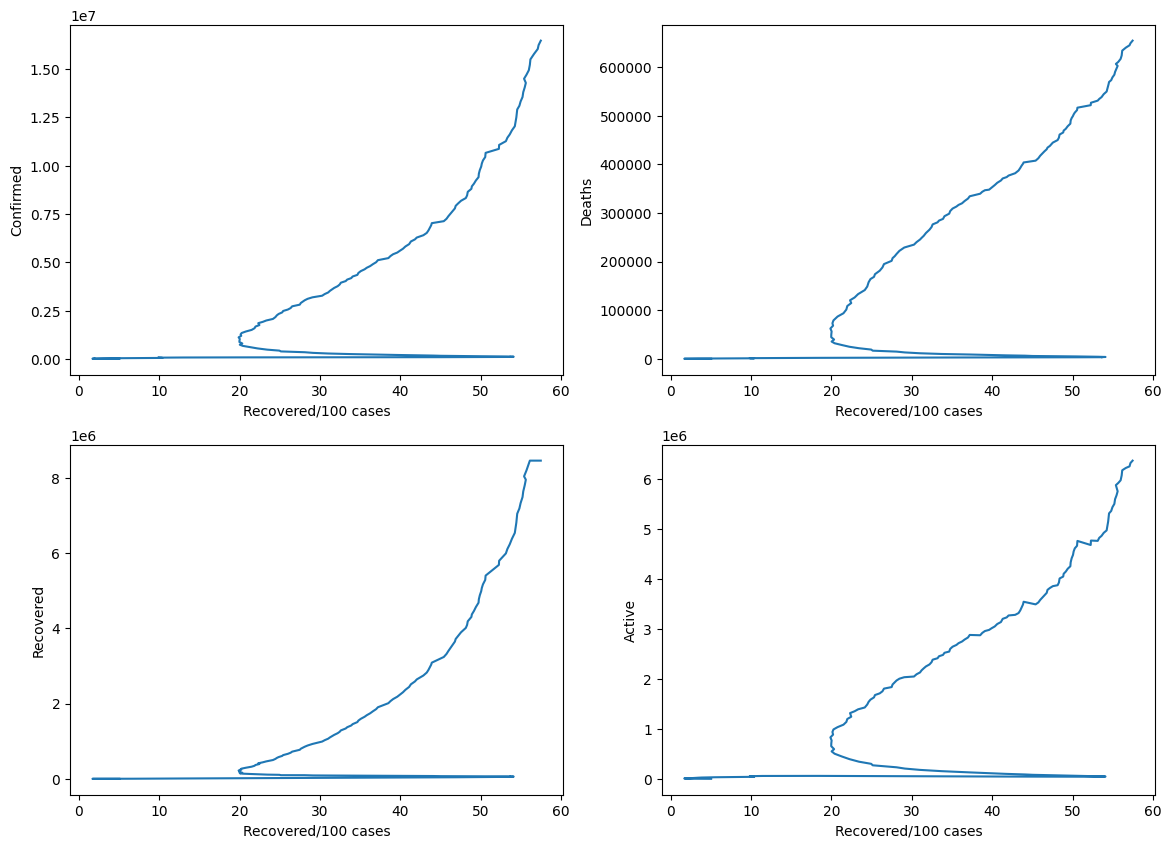

In [297]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[0]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Confirmed")

plt.subplot(2, 2, 2)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[1]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Deaths")

plt.subplot(2, 2, 3)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[2]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Recovered")

plt.subplot(2, 2, 4)
plt.plot(day_wise_df[num_col[-3]], day_wise_df[num_col[3]])
plt.xlabel("Recovered/100 cases")
plt.ylabel("Active")
plt.show()

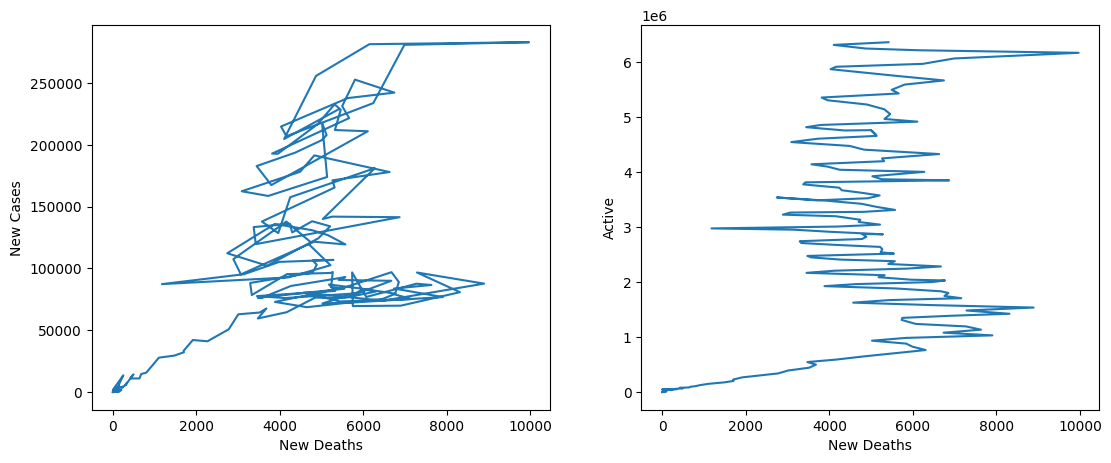

In [298]:
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(day_wise_df[num_col[5]], day_wise_df[num_col[4]])
plt.xlabel("New Deaths")
plt.ylabel("New Cases")

plt.subplot(1, 2, 2)
plt.plot(day_wise_df[num_col[5]], day_wise_df[num_col[3]])
plt.xlabel("New Deaths")
plt.ylabel("Active")

plt.show()

In [299]:
col_to_remove_ind = [num_col[-4]]
d3 = day_wise_df.drop(col_to_remove_ind, axis=1)

In [300]:
d3.columns

Index(['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases',
       'New deaths', 'New recovered', 'Recovered / 100 Cases',
       'Deaths / 100 Recovered', 'No. of countries'],
      dtype='object')

#### From the previous analysis we get:
* in the percentage of deaths /100 cases is less than th precentage of recovered/100 cases
* For Active, Recovered, Deaths and Confirmed Columns the Confirmed column takes the highest precentage and after that Active
* For New cases, New Recovered and New Deaths Columns the New cases column takes the highest precentage and after that New Recovered
* For Total cases, Total Recovered and Total Deaths Columns the Total cases column takes the highest precentage and after that Total Recovered
* There is a high change in covid 19 total different cases when the number of countries is greater than 175
* for Recovered/ 100 cases with number of countries the cases start with high value then it decreases then increaing starting from 150 to 175 then it decreases againg
* for Deaths/100 cases with the number of countries the cases start with small value then it reaches its global maximum value at 100 then it decreases then increases and so on
* As Deaths/100 cases has low correlation with target so it was removed

### Working with full_grouped dataset

In [301]:
col,num_col = cal_col(full_grouped_df)

In [302]:
full_grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB


In [303]:
full_grouped_df['Date'] = pd.to_datetime(full_grouped_df['Date'])

In [304]:
full_grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            35156 non-null  datetime64[ns]
 1   Country/Region  35156 non-null  object        
 2   Confirmed       35156 non-null  int64         
 3   Deaths          35156 non-null  int64         
 4   Recovered       35156 non-null  int64         
 5   Active          35156 non-null  int64         
 6   New cases       35156 non-null  int64         
 7   New deaths      35156 non-null  int64         
 8   New recovered   35156 non-null  int64         
 9   WHO Region      35156 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 2.7+ MB


In [305]:
full_grouped_df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [306]:
full_grouped_df.tail(10)

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
35146,2020-07-27,United Kingdom,301708,45844,1437,254427,688,7,3,Europe
35147,2020-07-27,Uruguay,1202,35,951,216,10,1,3,Americas
35148,2020-07-27,Uzbekistan,21209,121,11674,9414,678,5,569,Europe
35149,2020-07-27,Venezuela,15988,146,9959,5883,525,4,213,Americas
35150,2020-07-27,Vietnam,431,0,365,66,11,0,0,Western Pacific
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa
35155,2020-07-27,Zimbabwe,2704,36,542,2126,192,2,24,Africa


In [307]:
full_grouped_df[full_grouped_df['Country/Region']=='United Kingdom'].tail(20)

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
31593,2020-07-08,United Kingdom,288511,44602,1378,242531,637,126,3,Europe
31780,2020-07-09,United Kingdom,289154,44687,1378,243089,643,85,0,Europe
31967,2020-07-10,United Kingdom,289678,44735,1378,243565,524,48,0,Europe
32154,2020-07-11,United Kingdom,290504,44883,1378,244243,826,148,0,Europe
32341,2020-07-12,United Kingdom,291154,44904,1378,244872,650,21,0,Europe
32528,2020-07-13,United Kingdom,291691,44915,1384,245392,537,11,6,Europe
32715,2020-07-14,United Kingdom,292931,45053,1385,246493,1240,138,1,Europe
32902,2020-07-15,United Kingdom,293469,45138,1386,246945,538,85,1,Europe
33089,2020-07-16,United Kingdom,294116,45204,1403,247509,647,66,17,Europe
33276,2020-07-17,United Kingdom,294803,45318,1403,248082,687,114,0,Europe


In [308]:
full_grouped_df[num_col].describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000


In [309]:
full_grouped_df[full_grouped_df['New deaths']<0].count()

,0
Date,38
Country/Region,38
Confirmed,38
Deaths,38
Recovered,38
Active,38
New cases,38
New deaths,38
New recovered,38
WHO Region,38


In [310]:
# as there should be no negative values in deaths,recovered values then we are gonna to drop and if the percentage of them is big then we can get their abs val for them
cond = (full_grouped_df['New deaths'] >= 0) & (full_grouped_df['Active'] >= 0) & (full_grouped_df['New recovered'] >= 0)
new_data = full_grouped_df[cond].copy()

In [311]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35041 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            35041 non-null  datetime64[ns]
 1   Country/Region  35041 non-null  object        
 2   Confirmed       35041 non-null  int64         
 3   Deaths          35041 non-null  int64         
 4   Recovered       35041 non-null  int64         
 5   Active          35041 non-null  int64         
 6   New cases       35041 non-null  int64         
 7   New deaths      35041 non-null  int64         
 8   New recovered   35041 non-null  int64         
 9   WHO Region      35041 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 2.9+ MB


In [312]:
new_data.shape

(35041, 10)

In [313]:
percentage = (new_data.shape[0] / full_grouped_df.shape[0]) * 100
percentage

99.67288656274889

In [314]:
new_data[col].describe()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
count,35041,3.504100e+04,35041.000000,3.504100e+04,3.504100e+04,35041.000000,35041.000000,35041.000000
mean,2020-04-24 10:20:46.608259072,2.351692e+04,1227.798493,1.103168e+04,1.125744e+04,469.348906,18.590508,271.163808
min,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,2020-03-08 00:00:00,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
50%,2020-04-24 00:00:00,2.460000e+02,4.000000,3.300000e+01,8.400000e+01,2.000000,0.000000,0.000000
75%,2020-06-10 00:00:00,3.623000e+03,78.000000,1.279000e+03,1.454000e+03,74.000000,1.000000,20.000000
max,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.000000,3887.000000,140050.000000
std,NaN,1.500045e+05,7423.438095,6.459747e+04,8.992780e+04,3008.153287,114.807722,2067.557128


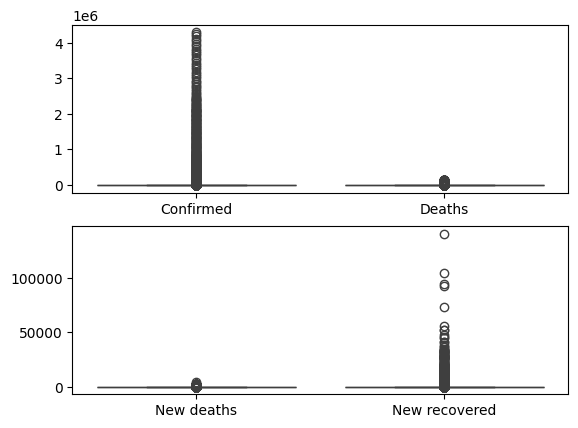

In [315]:
plt.subplot(2,1,1)
sns.boxplot(data= new_data[col[:4]])

plt.subplot(2,1,2)
sns.boxplot(data= new_data[col[-3:]])

plt.show()

In [316]:
for i in num_col:
    lower,upper = calculating_iqr(new_data,i)
    new_data[i] = new_data[i].apply(handle_outliers)

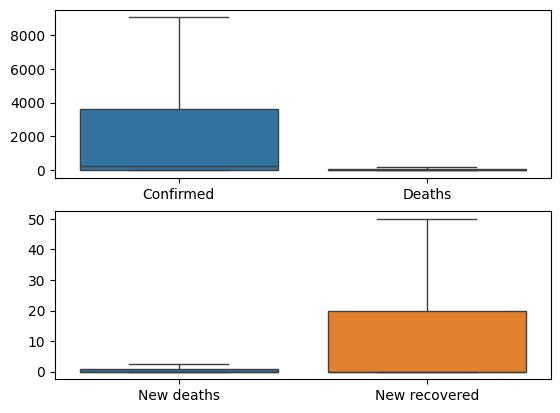

In [317]:
plt.subplot(2,1,1)
sns.boxplot(data= new_data[col[:4]])

plt.subplot(2,1,2)
sns.boxplot(data= new_data[col[-3:]])

plt.show()

In [318]:
new_data.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
1,2020-01-22,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Europe
2,2020-01-22,Algeria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Africa
3,2020-01-22,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Europe
4,2020-01-22,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Africa


In [319]:
new_data.tail()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
35151,2020-07-27,West Bank and Gaza,9056.0,78.0,3197.5,3635.0,152.0,2.0,0.0,Eastern Mediterranean
35152,2020-07-27,Western Sahara,10.0,1.0,8.0,1.0,0.0,0.0,0.0,Africa
35153,2020-07-27,Yemen,1691.0,195.0,833.0,375.0,10.0,2.5,36.0,Eastern Mediterranean
35154,2020-07-27,Zambia,4552.0,140.0,2815.0,1597.0,71.0,1.0,50.0,Africa
35155,2020-07-27,Zimbabwe,2704.0,36.0,542.0,2126.0,185.0,2.0,24.0,Africa


In [320]:
new_data.drop_duplicates(keep = 'first',inplace = True)
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35041 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            35041 non-null  datetime64[ns]
 1   Country/Region  35041 non-null  object        
 2   Confirmed       35041 non-null  float64       
 3   Deaths          35041 non-null  float64       
 4   Recovered       35041 non-null  float64       
 5   Active          35041 non-null  float64       
 6   New cases       35041 non-null  float64       
 7   New deaths      35041 non-null  float64       
 8   New recovered   35041 non-null  float64       
 9   WHO Region      35041 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 2.9+ MB


#### Plotting

In [321]:
col,num_col = cal_col(new_data)

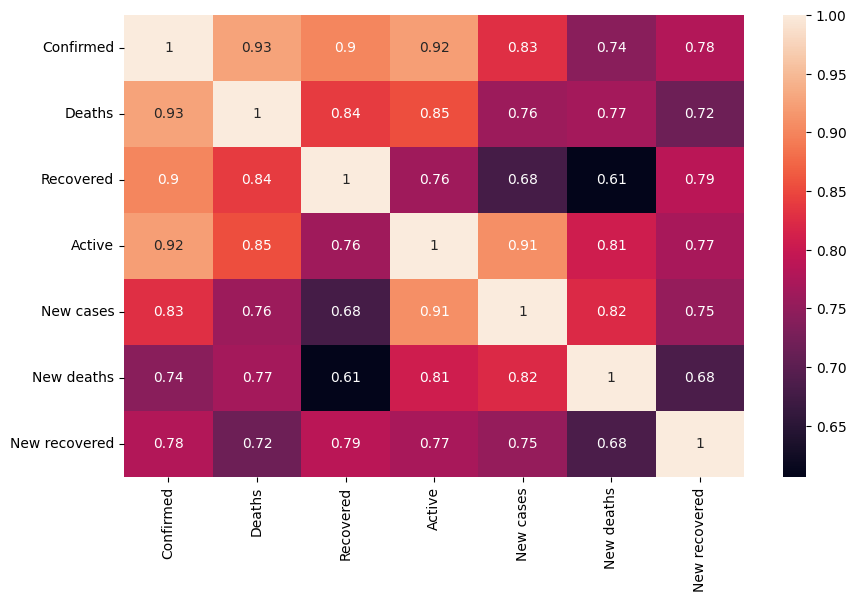

In [322]:
plt.figure(figsize=(10, 6))
cal_corr(num_col,new_data)

In [323]:
new_data['WHO Region'].unique()

array(['Eastern Mediterranean', 'Europe', 'Africa', 'Americas',
       'Western Pacific', 'South-East Asia'], dtype=object)

In [324]:
Total_cases_mean = new_data.groupby('WHO Region')['Confirmed'].mean()

Total_death_mean = new_data.groupby('WHO Region')['Deaths'].mean()

Total_recovered_mean = new_data.groupby('WHO Region')['Recovered'].mean()

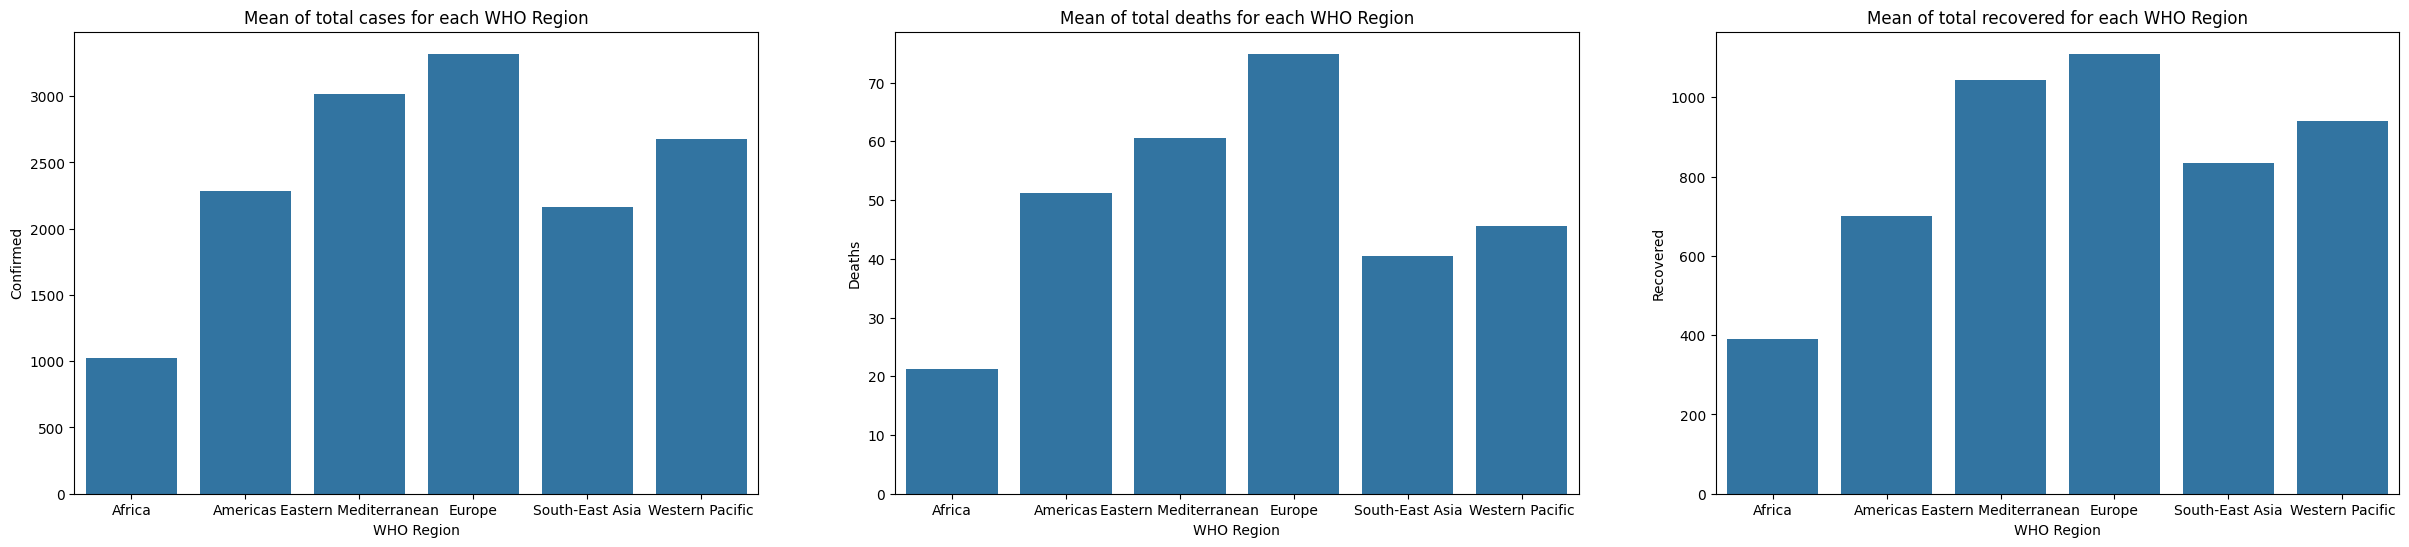

In [325]:
plt.figure(figsize=(30, 6))
plt.subplot(1,3,1)
sns.barplot(x = Total_cases_mean.index,y = Total_cases_mean.values )
plt.title('Mean of total cases for each WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Confirmed')

plt.subplot(1,3,2)
sns.barplot(x = Total_death_mean.index,y = Total_death_mean.values )
plt.title('Mean of total deaths for each WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Deaths')

plt.subplot(1,3,3)
sns.barplot(x = Total_recovered_mean.index,y = Total_recovered_mean.values )
plt.title('Mean of total recovered for each WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Recovered')
plt.show()

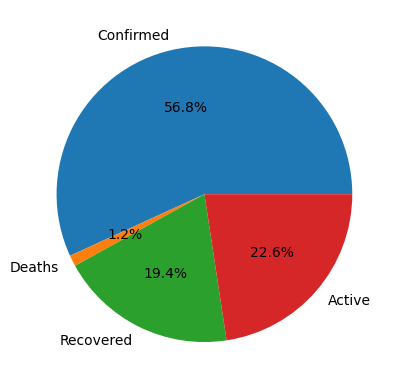

In [326]:
plt.pie(new_data[num_col[:4]].sum(),labels = num_col[:4],autopct = '%1.1F%%')
plt.show()

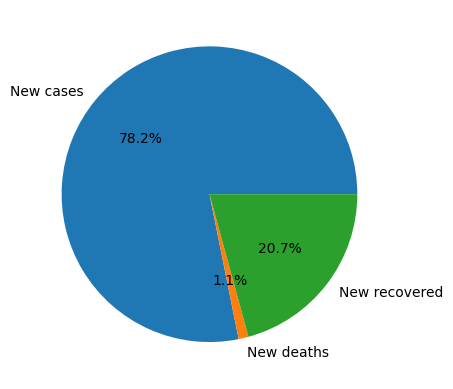

In [327]:
plt.pie(new_data[num_col[4:]].sum(),labels = num_col[4:],autopct = '%1.1F%%')
plt.show()

In [328]:
d4 = new_data

#### From the previous analysis we will found that
* WHO Region who takes the highest precentage for different cases in Covid 19 is Europe
* Active has high precentage than recovered

### Working with usa_county_wise dataset

In [329]:
col,num_col = cal_col(usa_county_wise_df)

In [330]:
usa_county_wise_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Date,Confirmed,Deaths
0,16,AS,ASM,16,60.0,NaN,American Samoa,US,-14.271000,-170.132000,"American Samoa, US",1/22/20,0,0
1,316,GU,GUM,316,66.0,NaN,Guam,US,13.444300,144.793700,"Guam, US",1/22/20,0,0
2,580,MP,MNP,580,69.0,NaN,Northern Mariana Islands,US,15.097900,145.673900,"Northern Mariana Islands, US",1/22/20,0,0
3,63072001,PR,PRI,630,72001.0,Adjuntas,Puerto Rico,US,18.180117,-66.754367,"Adjuntas, Puerto Rico, US",1/22/20,0,0
4,63072003,PR,PRI,630,72003.0,Aguada,Puerto Rico,US,18.360255,-67.175131,"Aguada, Puerto Rico, US",1/22/20,0,0


In [331]:
usa_county_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627920 entries, 0 to 627919
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   UID             627920 non-null  int64  
 1   iso2            627920 non-null  object 
 2   iso3            627920 non-null  object 
 3   code3           627920 non-null  int64  
 4   FIPS            626040 non-null  float64
 5   Admin2          626792 non-null  object 
 6   Province_State  627920 non-null  object 
 7   Country_Region  627920 non-null  object 
 8   Lat             627920 non-null  float64
 9   Long_           627920 non-null  float64
 10  Combined_Key    627920 non-null  object 
 11  Date            627920 non-null  object 
 12  Confirmed       627920 non-null  int64  
 13  Deaths          627920 non-null  int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 67.1+ MB


In [332]:
usa_county_wise_df[['Admin2','FIPS']].nunique()

,0
Admin2,1978
FIPS,3330


In [333]:
usa_county_wise_df[usa_county_wise_df['Admin2'].isna()][['Admin2','Combined_Key']].drop_duplicates()

,Admin2,Combined_Key
0,NaN,"American Samoa, US"
1,NaN,"Guam, US"
2,NaN,"Northern Mariana Islands, US"
81,NaN,"Virgin Islands, US"
3276,NaN,"Diamond Princess, US"
3329,NaN,"Grand Princess, US"


In [334]:
usa_county_wise_df[usa_county_wise_df['FIPS'].isna()][['Admin2','FIPS']].drop_duplicates()

,Admin2,FIPS
3330,Dukes and Nantucket,NaN
3331,Kansas City,NaN
3332,Michigan Department of Corrections (MDOC),NaN
3333,Federal Correctional Institution (FCI),NaN
3334,Bear River,NaN
3335,Central Utah,NaN
3336,Southeast Utah,NaN
3337,Southwest Utah,NaN
3338,TriCounty,NaN
3339,Weber-Morgan,NaN


In [335]:
usa_county_wise_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627920 entries, 0 to 627919
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   UID             627920 non-null  int64  
 1   iso2            627920 non-null  object 
 2   iso3            627920 non-null  object 
 3   code3           627920 non-null  int64  
 4   FIPS            626040 non-null  float64
 5   Admin2          626792 non-null  object 
 6   Province_State  627920 non-null  object 
 7   Country_Region  627920 non-null  object 
 8   Lat             627920 non-null  float64
 9   Long_           627920 non-null  float64
 10  Combined_Key    627920 non-null  object 
 11  Date            627920 non-null  object 
 12  Confirmed       627920 non-null  int64  
 13  Deaths          627920 non-null  int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 67.1+ MB


In [336]:
drop_na_df = usa_county_wise_df.dropna(how ='any',axis = 0).copy()
drop_na_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624912 entries, 3 to 627908
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   UID             624912 non-null  int64  
 1   iso2            624912 non-null  object 
 2   iso3            624912 non-null  object 
 3   code3           624912 non-null  int64  
 4   FIPS            624912 non-null  float64
 5   Admin2          624912 non-null  object 
 6   Province_State  624912 non-null  object 
 7   Country_Region  624912 non-null  object 
 8   Lat             624912 non-null  float64
 9   Long_           624912 non-null  float64
 10  Combined_Key    624912 non-null  object 
 11  Date            624912 non-null  object 
 12  Confirmed       624912 non-null  int64  
 13  Deaths          624912 non-null  int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 71.5+ MB


In [337]:
calculate_percentage = (drop_na_df.shape[0]/usa_county_wise_df.shape[0]) * 100
calculate_percentage

99.52095808383234

In [338]:
drop_na_df['Date'] = pd.to_datetime(drop_na_df['Date'],format='%m/%d/%y')

In [339]:
drop_na_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624912 entries, 3 to 627908
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   UID             624912 non-null  int64         
 1   iso2            624912 non-null  object        
 2   iso3            624912 non-null  object        
 3   code3           624912 non-null  int64         
 4   FIPS            624912 non-null  float64       
 5   Admin2          624912 non-null  object        
 6   Province_State  624912 non-null  object        
 7   Country_Region  624912 non-null  object        
 8   Lat             624912 non-null  float64       
 9   Long_           624912 non-null  float64       
 10  Combined_Key    624912 non-null  object        
 11  Date            624912 non-null  datetime64[ns]
 12  Confirmed       624912 non-null  int64         
 13  Deaths          624912 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4

In [340]:
drop_na_df['Country_Region'].unique()

array(['US'], dtype=object)

In [341]:
drop_na_df.rename(columns={'Long_': 'Long'}, inplace=True)

In [342]:
col,num_col = cal_col(drop_na_df)

#### Apply Plotting

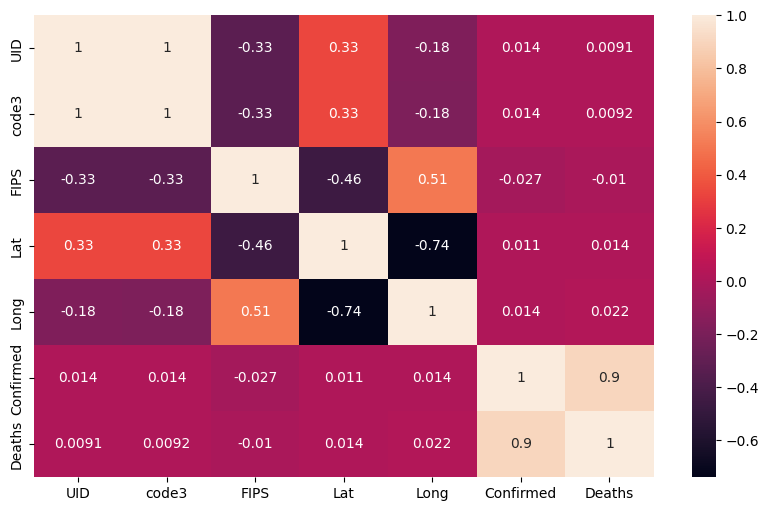

In [343]:
plt.figure(figsize=(10, 6))
cal_corr(num_col,drop_na_df)

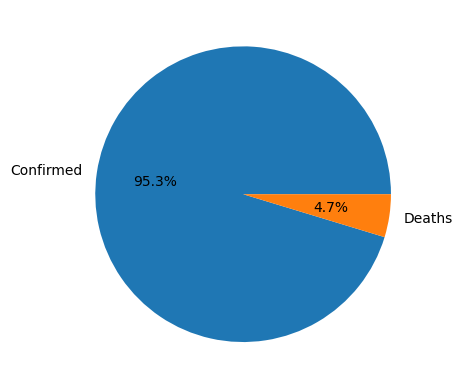

In [344]:
data = drop_na_df[num_col[-2:]].sum()
plt.pie(data,labels = num_col[-2:],autopct = '%1.1F%%')
plt.show()

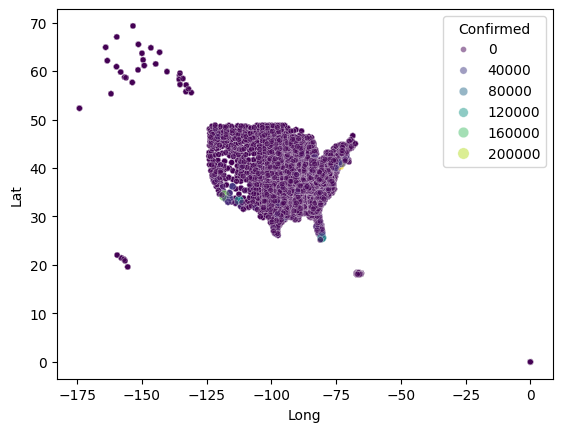

In [345]:
sns.scatterplot(
    data = drop_na_df,
    x = num_col[-3],
    y = num_col[-4],
    size = num_col[-2],
    hue = num_col[-2],
    palette="viridis",
    alpha=0.5,
)
plt.show()

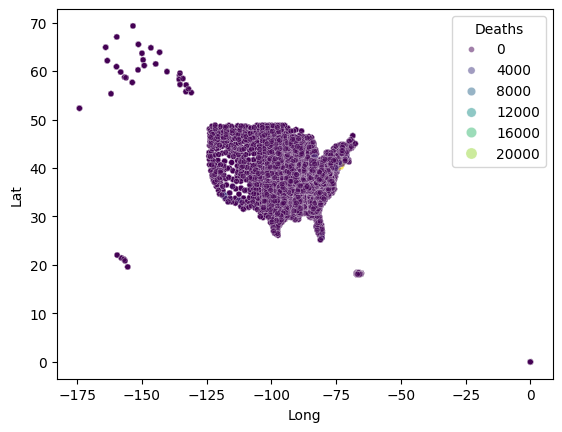

In [346]:
sns.scatterplot(
    data = drop_na_df,
    x = num_col[-3],
    y = num_col[-4],
    size = num_col[-1],
    hue = num_col[-1],
    palette="viridis",
    alpha=0.5,
)
plt.show()

In [347]:
d5 = drop_na_df[[num_col[-1],num_col[-2],'Country_Region']]

In [348]:
d5.columns

Index(['Deaths', 'Confirmed', 'Country_Region'], dtype='object')

#### From the pervious analysis
* we will find that a high percentage of confirmed and deaths in USA is in between -70 and -127 in longtitude and -25 to -50 in latitude  
* as the Country_Region column contains only usa value then it isn't gonna be useful in the model so we are gonna drop it
* as Combined_Key column are splitted into Admin2, Province_State, Country_Region columns so we can drop it  

### Working with worldometer_data dataset

In [349]:
col,num_col = cal_col(worldometer_data_df)

In [350]:
# getting precentage of data exist in each column
threshold = worldometer_data_df.shape[0] * 0.5
threshold

104.5

In [351]:
col_to_drop = worldometer_data_df.columns[worldometer_data_df.isna().sum() >= threshold]
col_to_drop

Index(['NewCases', 'NewDeaths', 'NewRecovered'], dtype='object')

In [352]:
worldometer_data_df.drop(col_to_drop, inplace = True,axis = 1)

In [353]:
worldometer_data_df.head()

,Country/Region,Continent,Population,TotalCases,TotalDeaths,TotalRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,162804.0,2576668.0,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,98644.0,2047660.0,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,41638.0,1377384.0,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,14606.0,676357.0,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,9604.0,387316.0,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [354]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country/Region    209 non-null    object 
 1   Continent         208 non-null    object 
 2   Population        208 non-null    float64
 3   TotalCases        209 non-null    int64  
 4   TotalDeaths       188 non-null    float64
 5   TotalRecovered    205 non-null    float64
 6   ActiveCases       205 non-null    float64
 7   Serious,Critical  122 non-null    float64
 8   Tot Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop     187 non-null    float64
 10  TotalTests        191 non-null    float64
 11  Tests/1M pop      191 non-null    float64
 12  WHO Region        184 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 21.4+ KB


In [355]:
# Renaming columns:
worldometer_data_df.rename(columns={'TotalCases': 'Total Cases','TotalDeaths':'Total Deaths','TotalRecovered':'Total Recovered','ActiveCases':'Active Cases','Serious,Critical':'Serious/Critical'\
                                   ,'Tot Cases/1M pop': 'Total Cases/1M pop', 'TotalTests':'Total Tests'}, inplace=True)

In [356]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      209 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         209 non-null    int64  
 4   Total Deaths        188 non-null    float64
 5   Total Recovered     205 non-null    float64
 6   Active Cases        205 non-null    float64
 7   Serious/Critical    122 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       187 non-null    float64
 10  Total Tests         191 non-null    float64
 11  Tests/1M pop        191 non-null    float64
 12  WHO Region          184 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 21.4+ KB


In [357]:
worldometer_data_df[worldometer_data_df['Continent'].isna()][['Continent','Country/Region']].drop_duplicates()

,Continent,Country/Region
156,NaN,Diamond Princess


In [358]:
worldometer_data_df[worldometer_data_df['Country/Region'] == 'Diamond Princess'][['Continent','Country/Region']]

,Continent,Country/Region
156,NaN,Diamond Princess


In [359]:
# dropping null values in 'Country/Region' and population
worldometer_data_df.dropna(subset = ['Country/Region','Population'],inplace = True)

In [360]:
worldometer_data_df[worldometer_data_df['WHO Region'].isna()][['WHO Region','Continent','Country/Region' ]]

,WHO Region,Continent,Country/Region
84,NaN,South America,French Guiana
102,NaN,Africa,CAR
112,NaN,Africa,Mayotte
158,NaN,Africa,Réunion
159,NaN,Europe,Channel Islands
167,NaN,Europe,Isle of Man
170,NaN,North America,Guadeloupe
171,NaN,North America,Martinique
172,NaN,Europe,Faeroe Islands
173,NaN,North America,Aruba


In [361]:
continent_dict = worldometer_data_df.groupby('Continent')['WHO Region'].first().to_dict()
continent_dict

{'Africa': 'Africa',
 'Asia': 'South-EastAsia',
 'Australia/Oceania': 'WesternPacific',
 'Europe': 'Europe',
 'North America': 'Americas',
 'South America': 'Americas'}

In [362]:
worldometer_data_df['WHO Region'] = worldometer_data_df['WHO Region'].fillna(worldometer_data_df['Continent'].map(continent_dict))

In [363]:
worldometer_data_df['WHO Region'].unique()

array(['Americas', 'South-EastAsia', 'Europe', 'Africa',
       'EasternMediterranean', 'WesternPacific'], dtype=object)

In [364]:
worldometer_data_df[worldometer_data_df['Total Tests'].isna()][['Total Tests','Tests/1M pop']]

,Total Tests,Tests/1M pop
54,NaN,NaN
82,NaN,NaN
86,NaN,NaN
106,NaN,NaN
108,NaN,NaN
111,NaN,NaN
130,NaN,NaN
138,NaN,NaN
142,NaN,NaN
145,NaN,NaN


In [365]:
# as Total Tests at least equals total cases then null values in total tests = total cases
worldometer_data_df['Total Tests'] = worldometer_data_df['Total Tests'].fillna(worldometer_data_df['Total Cases'])

In [366]:
# Total cases = Active + deaths + recovered
values_replaced_with = worldometer_data_df['Total Cases'] - (worldometer_data_df['Total Recovered'] + worldometer_data_df['Active Cases'])
worldometer_data_df['Total Deaths'] = worldometer_data_df['Total Deaths'].fillna(values_replaced_with)

In [367]:
col,num_col = cal_col(worldometer_data_df)

In [368]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      208 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         208 non-null    int64  
 4   Total Deaths        208 non-null    float64
 5   Total Recovered     204 non-null    float64
 6   Active Cases        204 non-null    float64
 7   Serious/Critical    121 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       187 non-null    float64
 10  Total Tests         208 non-null    float64
 11  Tests/1M pop        191 non-null    float64
 12  WHO Region          208 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 22.8+ KB


In [369]:
# Total cases = Active + deaths + recovered
values_replaced_with = worldometer_data_df['Total Cases'] - (worldometer_data_df['Total Deaths'] + worldometer_data_df['Active Cases'])
worldometer_data_df['Total Recovered'] = worldometer_data_df['Total Recovered'].fillna(values_replaced_with)

replace_values_in_test_percent = (worldometer_data_df['Total Tests'] / worldometer_data_df['Population'] ) *1000000
worldometer_data_df['Tests/1M pop'] = worldometer_data_df['Tests/1M pop'].fillna(replace_values_in_test_percent)

replace_values_in_test_percent = (worldometer_data_df['Total Deaths'] / worldometer_data_df['Population'] ) *1000000
worldometer_data_df['Deaths/1M pop'] = worldometer_data_df['Deaths/1M pop'].fillna(replace_values_in_test_percent)

In [370]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      208 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         208 non-null    int64  
 4   Total Deaths        208 non-null    float64
 5   Total Recovered     204 non-null    float64
 6   Active Cases        204 non-null    float64
 7   Serious/Critical    121 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       208 non-null    float64
 10  Total Tests         208 non-null    float64
 11  Tests/1M pop        208 non-null    float64
 12  WHO Region          208 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 22.8+ KB


In [371]:
worldometer_data_df = worldometer_data_df.fillna(0)

In [372]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      208 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         208 non-null    int64  
 4   Total Deaths        208 non-null    float64
 5   Total Recovered     208 non-null    float64
 6   Active Cases        208 non-null    float64
 7   Serious/Critical    208 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       208 non-null    float64
 10  Total Tests         208 non-null    float64
 11  Tests/1M pop        208 non-null    float64
 12  WHO Region          208 non-null    object 
dtypes: float64(9), int64(1), object(3)
memory usage: 22.8+ KB


In [373]:
worldometer_data_df[num_col] = worldometer_data_df[num_col].astype(int)

In [374]:
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country/Region      208 non-null    object
 1   Continent           208 non-null    object
 2   Population          208 non-null    int64 
 3   Total Cases         208 non-null    int64 
 4   Total Deaths        208 non-null    int64 
 5   Total Recovered     208 non-null    int64 
 6   Active Cases        208 non-null    int64 
 7   Serious/Critical    208 non-null    int64 
 8   Total Cases/1M pop  208 non-null    int64 
 9   Deaths/1M pop       208 non-null    int64 
 10  Total Tests         208 non-null    int64 
 11  Tests/1M pop        208 non-null    int64 
 12  WHO Region          208 non-null    object
dtypes: int64(10), object(3)
memory usage: 22.8+ KB


In [375]:
worldometer_data_df.describe()

,Population,Total Cases,Total Deaths,Total Recovered,Active Cases,Serious/Critical,Total Cases/1M pop,Deaths/1M pop,Total Tests,Tests/1M pop
count,2.080000e+02,2.080000e+02,208.000000,2.080000e+02,2.080000e+02,208.000000,208.000000,208.000000,2.080000e+02,208.000000
mean,3.041549e+07,9.215603e+04,3427.855769,5.802663e+04,2.726509e+04,313.423077,3196.024038,88.697115,1.288116e+06,77196.153846
std,1.047661e+08,4.335840e+05,14762.629768,2.549293e+05,1.733942e+05,1587.511422,5191.986457,168.512502,5.334286e+06,148082.071315
min,8.010000e+02,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,3.000000,0.000000,1.000000e+01,4.000000
25%,9.663140e+05,7.312500e+02,11.750000,3.070000e+02,7.400000e+01,0.000000,282.000000,4.000000,1.180775e+04,6494.000000
50%,7.041972e+06,4.544000e+03,73.000000,2.073500e+03,8.620000e+02,2.000000,1015.000000,20.000000,1.123535e+05,29793.500000
75%,2.575614e+07,3.733675e+04,604.250000,1.983525e+04,7.115750e+03,41.250000,3841.750000,82.000000,7.001068e+05,77340.500000
max,1.381345e+09,5.032179e+06,162804.000000,2.576668e+06,2.292707e+06,18296.000000,39922.000000,1238.000000,6.313960e+07,995282.000000


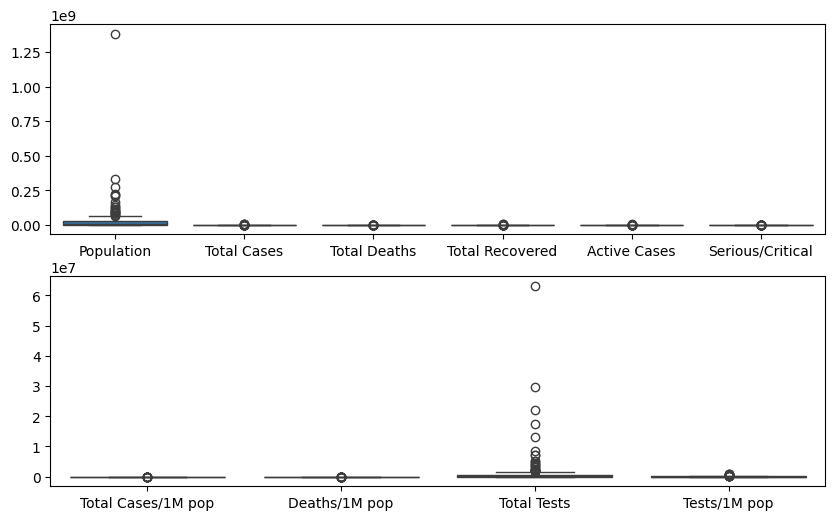

In [376]:
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
sns.boxplot(data= worldometer_data_df[num_col[:6]])

plt.subplot(2,1,2)
sns.boxplot(data= worldometer_data_df[num_col[6:]])

plt.show()

In [377]:
for i in num_col:
        lower,upper = calculating_iqr(worldometer_data_df,i)
        worldometer_data_df[i] = worldometer_data_df[i].apply(handle_outliers)

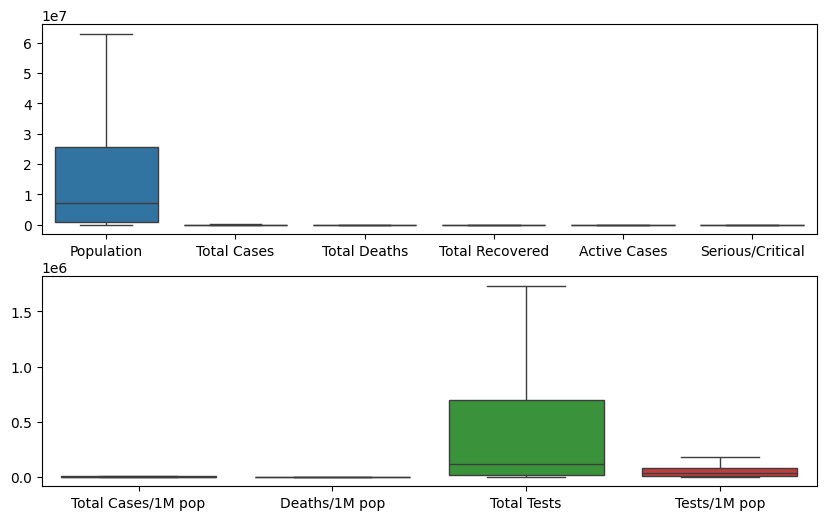

In [378]:
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
sns.boxplot(data= worldometer_data_df[num_col[:6]])

plt.subplot(2,1,2)
sns.boxplot(data= worldometer_data_df[num_col[6:]])

plt.show()

In [379]:
worldometer_data_df.drop_duplicates(keep = 'first',inplace = True)
worldometer_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 208
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Region      208 non-null    object 
 1   Continent           208 non-null    object 
 2   Population          208 non-null    float64
 3   Total Cases         208 non-null    float64
 4   Total Deaths        208 non-null    float64
 5   Total Recovered     208 non-null    float64
 6   Active Cases        208 non-null    float64
 7   Serious/Critical    208 non-null    float64
 8   Total Cases/1M pop  208 non-null    float64
 9   Deaths/1M pop       208 non-null    float64
 10  Total Tests         208 non-null    float64
 11  Tests/1M pop        208 non-null    float64
 12  WHO Region          208 non-null    object 
dtypes: float64(10), object(3)
memory usage: 22.8+ KB


#### Apply Plotting

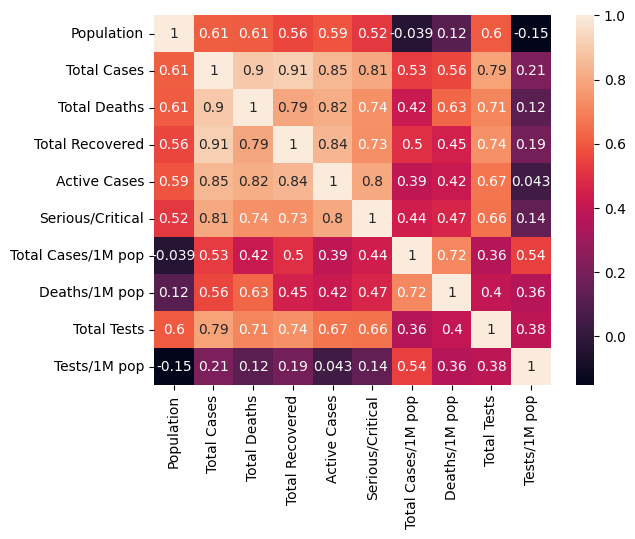

In [380]:
cal_corr(num_col,worldometer_data_df)

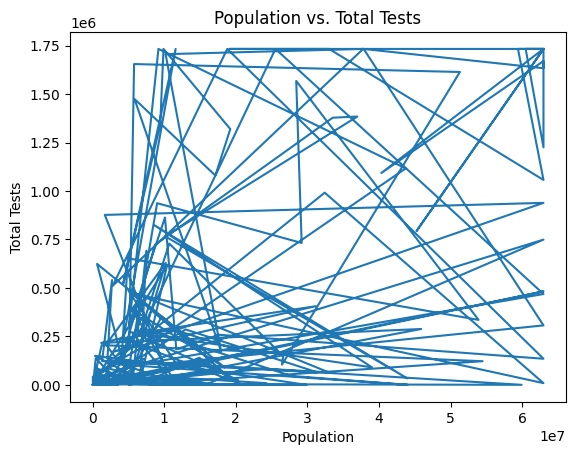

In [381]:
plt.plot( worldometer_data_df[num_col[0]], worldometer_data_df[num_col[-2]])
plt.title("Population vs. Total Tests")
plt.xlabel("Population")
plt.ylabel("Total Tests")
plt.show()

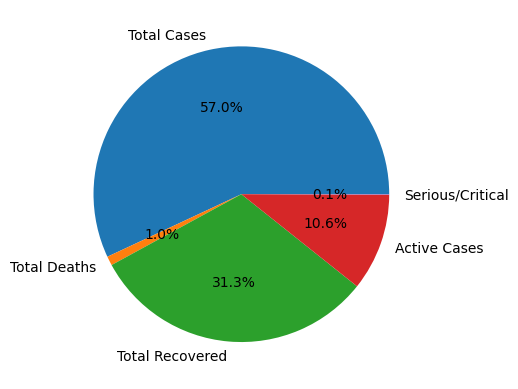

In [382]:
data = worldometer_data_df[num_col[1:6]].sum()
plt.pie(data,labels = num_col[1:6],autopct = '%1.1F%%')
plt.show()

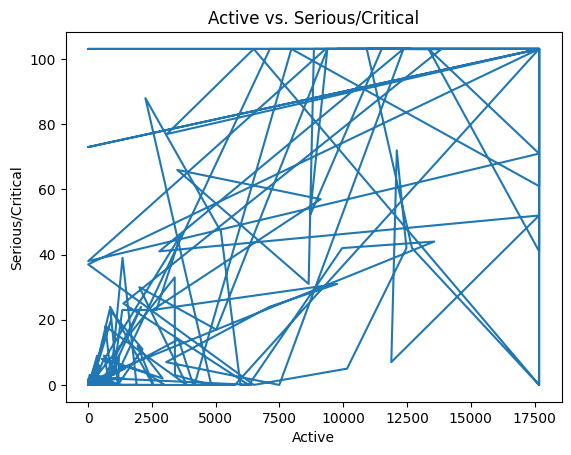

In [383]:
plt.plot( worldometer_data_df[num_col[4]], worldometer_data_df[num_col[5]])
plt.title("Active vs. Serious/Critical")
plt.xlabel("Active")
plt.ylabel("Serious/Critical")
plt.show()

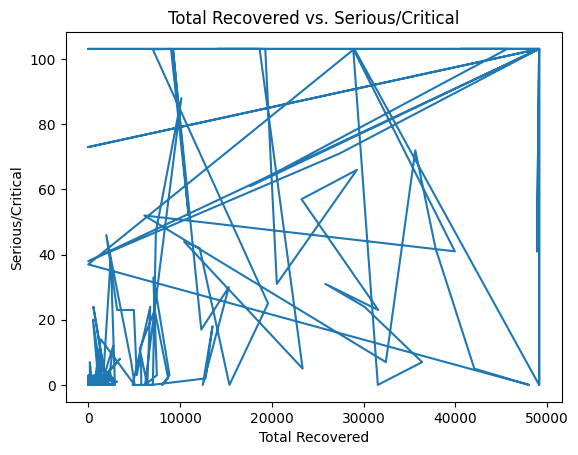

In [384]:
plt.plot( worldometer_data_df[num_col[3]], worldometer_data_df[num_col[5]])
plt.title("Total Recovered vs. Serious/Critical")
plt.xlabel("Total Recovered")
plt.ylabel("Serious/Critical")
plt.show()

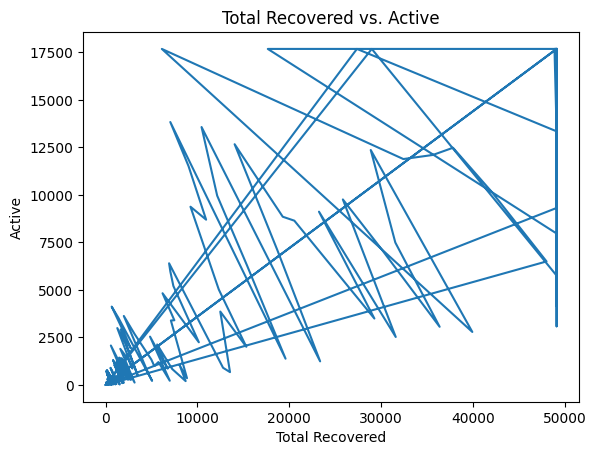

In [385]:
plt.plot( worldometer_data_df[num_col[3]], worldometer_data_df[num_col[4]])
plt.title("Total Recovered vs. Active")
plt.xlabel("Total Recovered")
plt.ylabel("Active")
plt.show()

In [386]:
worldometer_data_df[num_col[1:6]].sum()

,0
Total Cases,4906916.000
Total Deaths,86361.000
Total Recovered,2700385.750
Active Cases,916791.125
Serious/Critical,5400.375


In [387]:
labels = ['Total Cases','Total Deaths','Total Recovered','Active Cases','Serious/Critical']
vals = list(worldometer_data_df[num_col[1:6]].sum())

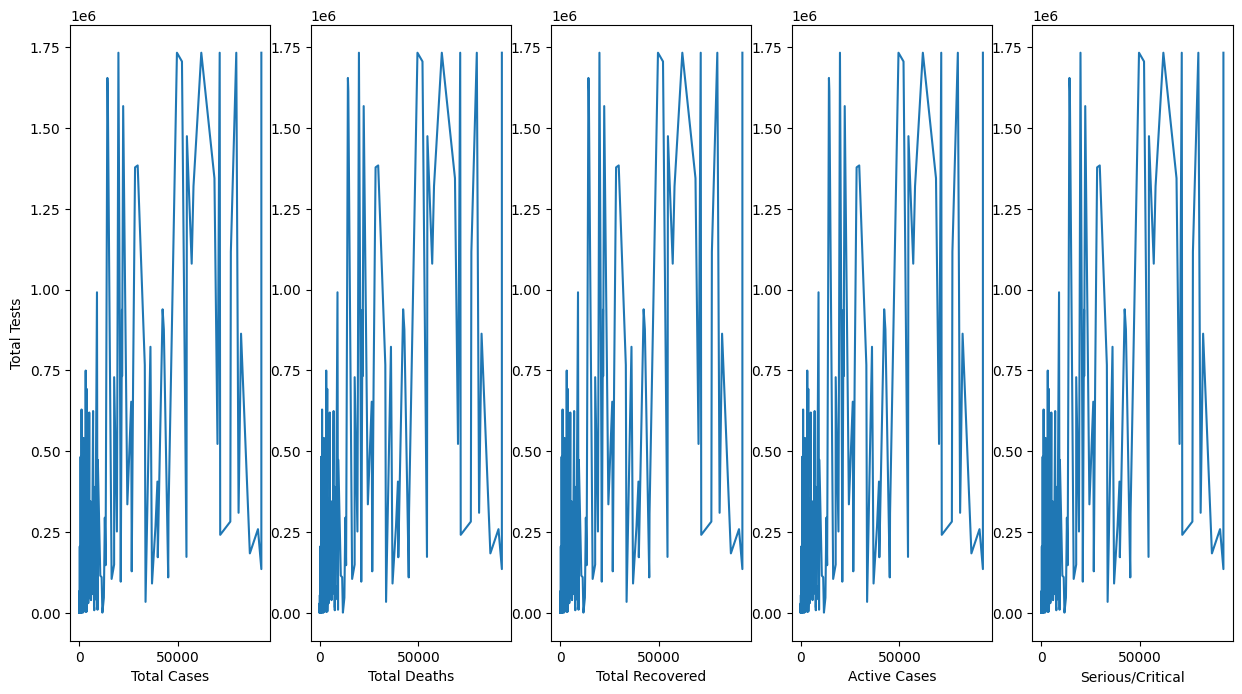

In [388]:
plt.figure(figsize=(15, 8))

plt.subplot(1,5,1)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Total Cases")
plt.ylabel("Total Tests")

plt.subplot(1,5,2)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Total Deaths")

plt.subplot(1,5,3)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Total Recovered")

plt.subplot(1,5,4)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Active Cases")

plt.subplot(1,5,5)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[-2]])
plt.xlabel("Serious/Critical")
plt.show()

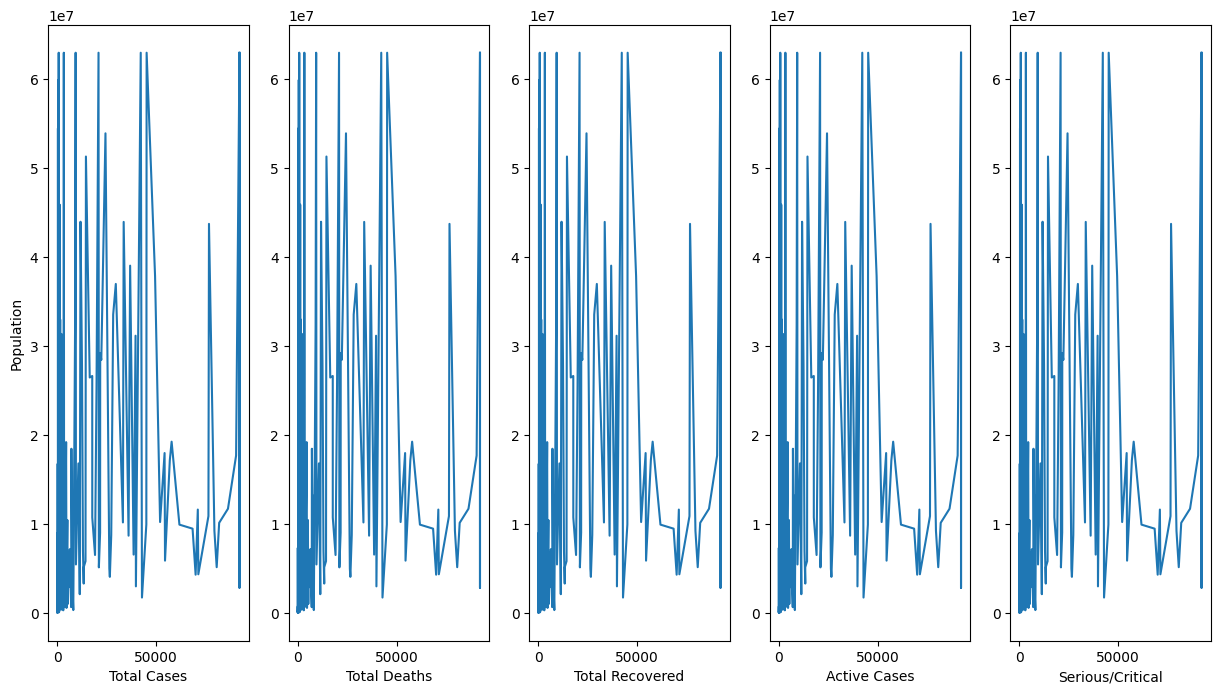

In [389]:
plt.figure(figsize=(15, 8))

plt.subplot(1,5,1)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Total Cases")
plt.ylabel("Population")

plt.subplot(1,5,2)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Total Deaths")

plt.subplot(1,5,3)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Total Recovered")

plt.subplot(1,5,4)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Active Cases")

plt.subplot(1,5,5)
plt.plot( worldometer_data_df[num_col[1]], worldometer_data_df[num_col[0]])
plt.xlabel("Serious/Critical")
plt.show()

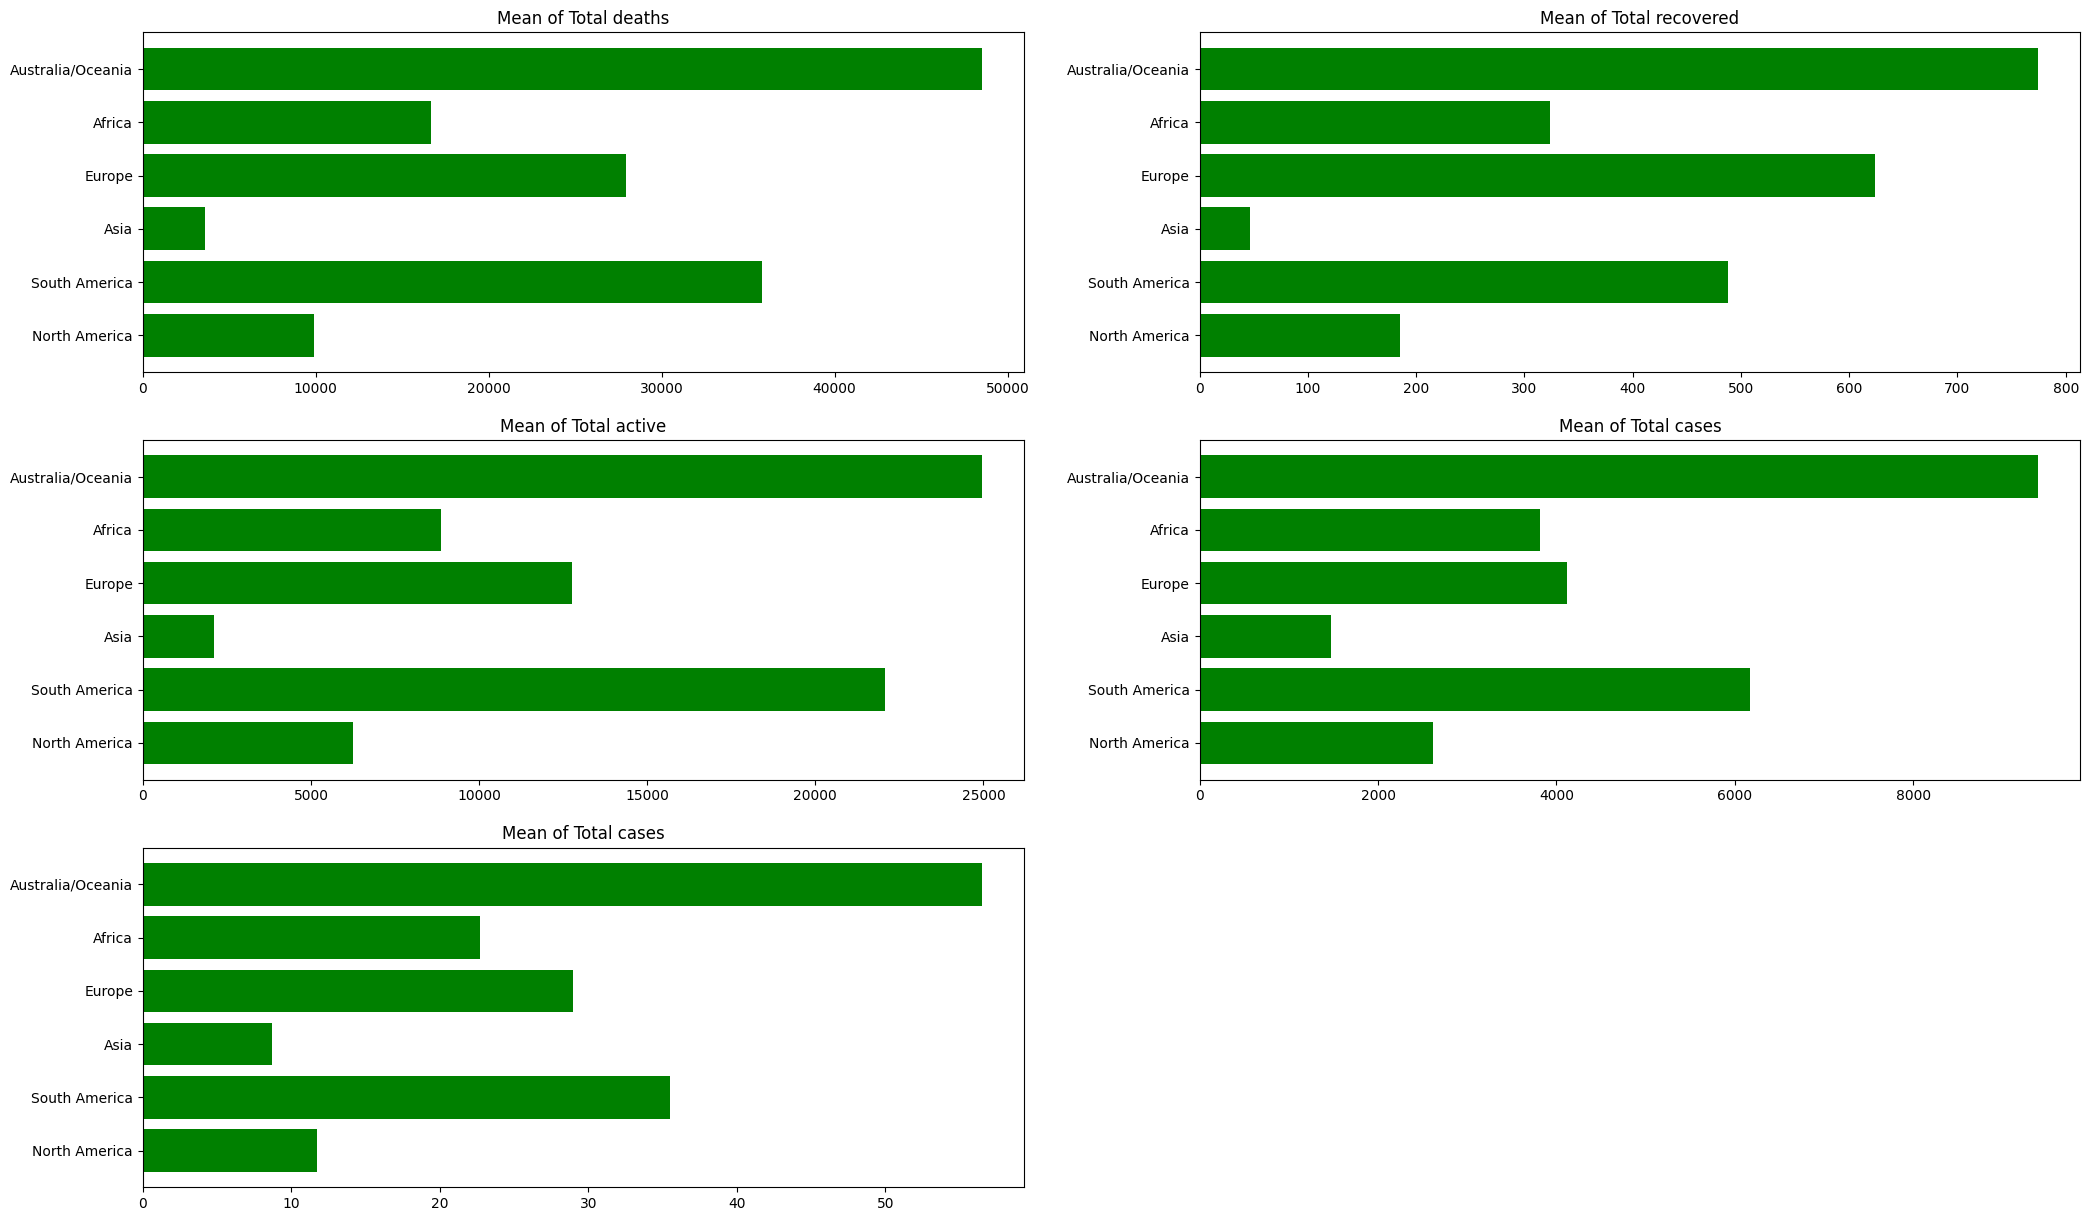

In [390]:
plt.figure(figsize=(25, 15))
plt.subplot(3,2,1)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Total Cases'].mean(),color = 'green')
plt.title('Mean of Total deaths')

plt.subplot(3,2,2)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Total Deaths'].mean(),color = 'green')
plt.title('Mean of Total recovered')

plt.subplot(3,2,3)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Total Recovered'].mean(),color = 'green')
plt.title('Mean of Total active')

plt.subplot(3,2,4)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Active Cases'].mean(),color = 'green')
plt.title('Mean of Total cases')

plt.subplot(3,2,5)
plt.barh(worldometer_data_df['Continent'].unique(),worldometer_data_df.groupby('Continent')['Serious/Critical'].mean(),color = 'green')
plt.title('Mean of Total cases')

plt.show()

In [391]:
col_to_remove_ind = [num_col[-1]]
d6 = worldometer_data_df.drop(col_to_remove_ind, axis=1)

In [392]:
d6.columns

Index(['Country/Region', 'Continent', 'Population', 'Total Cases',
       'Total Deaths', 'Total Recovered', 'Active Cases', 'Serious/Critical',
       'Total Cases/1M pop', 'Deaths/1M pop', 'Total Tests', 'WHO Region'],
      dtype='object')

#### From previous analysis:
* Serious/Critical case take the least precentage in all different cases
* at some point there is a peak where (total deaths, total cases, total recovered, active cases, serious/critical) when ploting it with population
* Over different cases Ausralia/Ocieania Contient has the highest mean\
* As Tests/1M pop has low correlation with the target then it will be removed

### Combining between datasets

In [393]:
# country_wise dataset
d1.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Confirmed last week',
       '1 week change', 'WHO Region'],
      dtype='object')

In [394]:
d1.shape

(187, 11)

In [395]:
# covid_19_clean_complete dataset
d2.columns

Index(['Country/Region', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'WHO Region'],
      dtype='object')

In [396]:
d2.shape

(49068, 7)

In [397]:
# day_wise dataset
d3.columns

Index(['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases',
       'New deaths', 'New recovered', 'Recovered / 100 Cases',
       'Deaths / 100 Recovered', 'No. of countries'],
      dtype='object')

In [398]:
d3.shape

(188, 11)

In [399]:
# full_grouped dataset
d4.columns

Index(['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region'],
      dtype='object')

In [400]:
d4.shape

(35041, 10)

In [401]:
# usa_county_wise dataset
d5.columns

Index(['Deaths', 'Confirmed', 'Country_Region'], dtype='object')

In [402]:
d5.shape

(624912, 3)

In [403]:
# worldometer_data dataset
d6.columns

Index(['Country/Region', 'Continent', 'Population', 'Total Cases',
       'Total Deaths', 'Total Recovered', 'Active Cases', 'Serious/Critical',
       'Total Cases/1M pop', 'Deaths/1M pop', 'Total Tests', 'WHO Region'],
      dtype='object')

In [404]:
d6.shape

(208, 12)

##### Merging

In [405]:
# d2 and d4
merged_df = pd.merge(d2, d4, on=['Country/Region','Date'], how='outer')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50007 entries, 0 to 50006
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  50007 non-null  object        
 1   Date            50007 non-null  datetime64[ns]
 2   Confirmed_x     49068 non-null  float64       
 3   Deaths_x        49068 non-null  float64       
 4   Recovered_x     49068 non-null  float64       
 5   Active_x        49068 non-null  float64       
 6   WHO Region_x    49068 non-null  object        
 7   Confirmed_y     48847 non-null  float64       
 8   Deaths_y        48847 non-null  float64       
 9   Recovered_y     48847 non-null  float64       
 10  Active_y        48847 non-null  float64       
 11  New cases       48847 non-null  float64       
 12  New deaths      48847 non-null  float64       
 13  New recovered   48847 non-null  float64       
 14  WHO Region_y    48847 non-null  object        
dtypes:

In [406]:
# who region handling
merged_df['WHO Region']  = merged_df['WHO Region_x'].fillna(merged_df['WHO Region_y'])
col_to_drop = ['WHO Region_x','WHO Region_y']

In [407]:
merged_df[merged_df['Confirmed_x'].isna()][['Confirmed_x','Confirmed_y']]

,Confirmed_x,Confirmed_y
6392,NaN,0.0
6393,NaN,0.0
6394,NaN,0.0
6395,NaN,0.0
6396,NaN,0.0
...,...,...
45490,NaN,9056.0
45491,NaN,9056.0
45492,NaN,9056.0
45493,NaN,9056.0


In [408]:
merged_df[['Deaths_x','Deaths_y']]

,Deaths_x,Deaths_y
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
50002,28.0,28.0
50003,32.0,32.0
50004,34.0,34.0
50005,34.0,34.0


In [409]:
merged_df[merged_df['Deaths_x'].isna()][['Deaths_x','Deaths_y']]

,Deaths_x,Deaths_y
6392,NaN,0.0
6393,NaN,0.0
6394,NaN,0.0
6395,NaN,0.0
6396,NaN,0.0
...,...,...
45490,NaN,195.0
45491,NaN,195.0
45492,NaN,195.0
45493,NaN,195.0


In [410]:
merged_df[['Recovered_x','Recovered_y']]

,Recovered_x,Recovered_y
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
50002,510.0,510.0
50003,514.0,514.0
50004,518.0,518.0
50005,518.0,518.0


In [411]:
merged_df[merged_df['Recovered_x'].isna()][['Recovered_x','Recovered_y']]

,Recovered_x,Recovered_y
6392,NaN,0.0
6393,NaN,0.0
6394,NaN,0.0
6395,NaN,0.0
6396,NaN,0.0
...,...,...
45490,NaN,3197.5
45491,NaN,3197.5
45492,NaN,3197.5
45493,NaN,3197.5


In [412]:
# Handling confirmed, deaths, recovered, active
# 1 confirmed
merged_df['Confirmed_x']  = merged_df['Confirmed_x'].fillna(merged_df['Confirmed_y'])

merged_df['Deaths_x']  = merged_df['Deaths_x'].fillna(merged_df['Deaths_y'])

merged_df['Recovered_x']  = merged_df['Recovered_x'].fillna(merged_df['Recovered_y'])

merged_df['Active_x']  = merged_df['Active_x'].fillna(merged_df['Active_y'])

In [413]:
col_to_drop = col_to_drop + ['Deaths_y','Recovered_y','Active_y','Confirmed_y']

In [414]:
# Renaming colums
merged_df.rename(columns={'Deaths_x': 'Deaths','Recovered_x':'Recovered','Active_x':'Active','Confirmed_x': 'Confirmed'}, inplace=True)

In [415]:
merged_df.drop(col_to_drop, axis=1,inplace = True)

In [416]:
# for each null value in the same country get the previous day date
# Get the value in the column needed
# substract it from the value i am in
# put the result in the null value
col_need = ['New cases','New deaths','New recovered']
merged_df[col_need]= merged_df.groupby(['Country/Region','Date'])[col_need].ffill()

In [417]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50007 entries, 0 to 50006
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  50007 non-null  object        
 1   Date            50007 non-null  datetime64[ns]
 2   Confirmed       50007 non-null  float64       
 3   Deaths          50007 non-null  float64       
 4   Recovered       50007 non-null  float64       
 5   Active          50007 non-null  float64       
 6   New cases       48847 non-null  float64       
 7   New deaths      48847 non-null  float64       
 8   New recovered   48847 non-null  float64       
 9   WHO Region      50007 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 3.8+ MB


confirmed [i+1] = total conf[i]
deaths[i+1] = total death[i]
recovered[i+1] = total recovered[i]

In [418]:
# sort based on
merged_df.sort_values(by=['Country/Region','Date'],inplace =True)

In [419]:
# confirmed-new = confirmed-pre + new cases
new_de_rep = merged_df.groupby('Country/Region')['Deaths'].shift(1)
merged_df['New deaths'] = merged_df['New deaths'].fillna(merged_df['Deaths'] - new_de_rep)

new_co_rep = merged_df.groupby('Country/Region')['Confirmed'].shift(1)
merged_df['New cases'] = merged_df['New cases'].fillna(merged_df['Confirmed'] - new_co_rep)

new_re_rep = merged_df.groupby('Country/Region')['Recovered'].shift(1)
merged_df['New recovered'] = merged_df['New recovered'].fillna(merged_df['Recovered'] - new_re_rep)

In [420]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50007 entries, 0 to 50006
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  50007 non-null  object        
 1   Date            50007 non-null  datetime64[ns]
 2   Confirmed       50007 non-null  float64       
 3   Deaths          50007 non-null  float64       
 4   Recovered       50007 non-null  float64       
 5   Active          50007 non-null  float64       
 6   New cases       50003 non-null  float64       
 7   New deaths      50003 non-null  float64       
 8   New recovered   50003 non-null  float64       
 9   WHO Region      50007 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 3.8+ MB


In [421]:
merged_df[(merged_df['New cases'].isna())|(merged_df['New deaths'].isna())|(merged_df['New recovered'].isna())][['Country/Region','New cases','New deaths','New recovered']]

,Country/Region,New cases,New deaths,New recovered
16732,Congo,NaN,NaN,NaN
18612,Côte d'Ivoire,NaN,NaN,NaN
34216,Myanmar,NaN,NaN,NaN
45495,USA,NaN,NaN,NaN


In [422]:
merged_df = merged_df.fillna(0)

In [423]:
# Drop duplicates based on columns
merged_df = merged_df.copy()
merged_df = merged_df.drop_duplicates(subset = ['Country/Region','Date']).reset_index(drop = True)
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35907 entries, 0 to 35906
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  35907 non-null  object        
 1   Date            35907 non-null  datetime64[ns]
 2   Confirmed       35907 non-null  float64       
 3   Deaths          35907 non-null  float64       
 4   Recovered       35907 non-null  float64       
 5   Active          35907 non-null  float64       
 6   New cases       35907 non-null  float64       
 7   New deaths      35907 non-null  float64       
 8   New recovered   35907 non-null  float64       
 9   WHO Region      35907 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 2.7+ MB


In [424]:
merged_df.head(25)

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,Afghanistan,2020-01-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
1,Afghanistan,2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
2,Afghanistan,2020-01-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
3,Afghanistan,2020-01-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
4,Afghanistan,2020-01-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
5,Afghanistan,2020-01-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
6,Afghanistan,2020-01-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
7,Afghanistan,2020-01-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
8,Afghanistan,2020-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean
9,Afghanistan,2020-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Eastern Mediterranean


In [425]:
merged_df.tail(25)

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
35882,Zimbabwe,2020-07-03,625.0,7.0,176.0,442.0,8.0,0.0,3.0,Africa
35883,Zimbabwe,2020-07-04,698.0,8.0,181.0,509.0,73.0,1.0,5.0,Africa
35884,Zimbabwe,2020-07-05,716.0,8.0,181.0,527.0,18.0,0.0,0.0,Africa
35885,Zimbabwe,2020-07-06,734.0,9.0,197.0,528.0,18.0,1.0,16.0,Africa
35886,Zimbabwe,2020-07-07,787.0,9.0,201.0,577.0,53.0,0.0,4.0,Africa
35887,Zimbabwe,2020-07-08,885.0,9.0,206.0,670.0,98.0,0.0,5.0,Africa
35888,Zimbabwe,2020-07-09,885.0,9.0,206.0,670.0,0.0,0.0,0.0,Africa
35889,Zimbabwe,2020-07-10,942.0,13.0,320.0,609.0,57.0,2.5,50.0,Africa
35890,Zimbabwe,2020-07-11,982.0,18.0,320.0,644.0,40.0,2.5,0.0,Africa
35891,Zimbabwe,2020-07-12,985.0,18.0,328.0,639.0,3.0,0.0,8.0,Africa


In [426]:
col,num_col = cal_col(merged_df)

In [427]:
for i in num_col:
  merged_df[i] = np.ceil(merged_df[i]).astype('Int64')
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35907 entries, 0 to 35906
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  35907 non-null  object        
 1   Date            35907 non-null  datetime64[ns]
 2   Confirmed       35907 non-null  Int64         
 3   Deaths          35907 non-null  Int64         
 4   Recovered       35907 non-null  Int64         
 5   Active          35907 non-null  Int64         
 6   New cases       35907 non-null  Int64         
 7   New deaths      35907 non-null  Int64         
 8   New recovered   35907 non-null  Int64         
 9   WHO Region      35907 non-null  object        
dtypes: Int64(7), datetime64[ns](1), object(2)
memory usage: 3.0+ MB


In [428]:
merged_df.tail(25)

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
35882,Zimbabwe,2020-07-03,625,7,176,442,8,0,3,Africa
35883,Zimbabwe,2020-07-04,698,8,181,509,73,1,5,Africa
35884,Zimbabwe,2020-07-05,716,8,181,527,18,0,0,Africa
35885,Zimbabwe,2020-07-06,734,9,197,528,18,1,16,Africa
35886,Zimbabwe,2020-07-07,787,9,201,577,53,0,4,Africa
35887,Zimbabwe,2020-07-08,885,9,206,670,98,0,5,Africa
35888,Zimbabwe,2020-07-09,885,9,206,670,0,0,0,Africa
35889,Zimbabwe,2020-07-10,942,13,320,609,57,3,50,Africa
35890,Zimbabwe,2020-07-11,982,18,320,644,40,3,0,Africa
35891,Zimbabwe,2020-07-12,985,18,328,639,3,0,8,Africa


### Saving Data into csv files

In [429]:
merged_df.to_csv('Covid_19_dataset.csv',index = False)

In [430]:
d5.to_csv("Covid_19_usa_datset.csv",index = False)